In [1]:
import pandas as pd
from pathlib import Path
import re

# Base directory of the project
base_dir = Path(r"c:/Users/nhphuong/Desktop/Solar/")

# Month folders, area, and base filenames (without extension)
month_specs = [
    ("apr_2025", "Area_1", "april_fivemin_power"),
    ("may_2025", "Area_1", "may_fivemin_power"),
    ("jun_2025", "Area_1", "june_fivemin_power"),
    ("jul_2025", "Area_1", "july_fivemin_power"),
    ("aug_2025", "Area_1", "august_fivemin_power"),
    ("sep_2025", "Area_1", "september_fivemin_power"),
]

expected_eu_cols = [f"eu_{i}" for i in range(1, 25)]
all_dfs = []

for folder, area, fname in month_specs:
    base_path = base_dir / folder / area / fname

    # Try common extensions; adjust if your files use a different one
    file_path = None
    for ext in (".csv", ".parquet"):
        candidate = base_path.with_suffix(ext)
        if candidate.exists():
            file_path = candidate
            break

    if file_path is None:
        raise FileNotFoundError(f"No file found for {base_path} with expected extensions (.csv, .parquet)")

    if file_path.suffix == ".csv":
        df = pd.read_csv(file_path)
    elif file_path.suffix == ".parquet":
        df = pd.read_parquet(file_path)
    else:
        raise ValueError(f"Unsupported file type: {file_path.suffix}")

    # Ensure we have the time column
    time_col = None
    for c in df.columns:
        if c.lower().startswith("time"):
            time_col = c
            break
    if time_col is None:
        raise KeyError("No time column found (expected something like 'time (min)')")

    # Build mapping from raw EU columns (e.g., "eu_5 (kW)") to normalized names (e.g., "eu_5")
    eu_map = {}
    for c in df.columns:
        match = re.match(r"^eu_(\d+)", c.strip().lower())
        if match:
            eu_idx = int(match.group(1))
            if 1 <= eu_idx <= 24 and f"eu_{eu_idx}" not in eu_map:
                eu_map[f"eu_{eu_idx}"] = c

    # Keep time + all expected EU columns; fill missing EUs with zeros
    out_df = pd.DataFrame({"time": df[time_col]})
    for eu_col in expected_eu_cols:
        if eu_col in eu_map:
            out_df[eu_col] = df[eu_map[eu_col]]
        else:
            out_df[eu_col] = 0

    all_dfs.append(out_df)

# Combined DataFrame with eu_1–eu_24 from all months
combined_df = pd.concat(all_dfs, ignore_index=True)

# Optionally save combined_df to CSV
save_combined = True # set to True to save
output_csv_path = base_dir / "all_data" / "combined_apr_sep_2025_area1.csv"

if save_combined:
    output_csv_path.parent.mkdir(parents=True, exist_ok=True)
    combined_df.to_csv(output_csv_path, index=False)
    print(f"combined_df saved to: {output_csv_path}")

combined_df.head()

combined_df saved to: c:\Users\nhphuong\Desktop\Solar\all_data\combined_apr_sep_2025_area1.csv


,time,eu_1,eu_2,eu_3,eu_4,eu_5,eu_6,eu_7,eu_8,eu_9,...,eu_15,eu_16,eu_17,eu_18,eu_19,eu_20,eu_21,eu_22,eu_23,eu_24
0,2025-04-18 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025-04-18 00:05:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025-04-18 00:10:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2025-04-18 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025-04-18 00:20:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Exploratory Data Analysis — Solar Panel Power (Area 1, Apr–Sep 2025)
24 panels (`eu_1`–`eu_24`), 5-minute resolution power readings in Watts.

## 1. Data Profiling

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (14, 5)})

eu_cols = [f"eu_{i}" for i in range(1, 25)]

# Parse time column
combined_df["time"] = pd.to_datetime(combined_df["time"])
combined_df = combined_df.sort_values("time").reset_index(drop=True)

print(f"Shape: {combined_df.shape}")
print(f"Date range: {combined_df['time'].min()} → {combined_df['time'].max()}")
print(f"Time step (mode): {combined_df['time'].diff().mode().iloc[0]}")
print(f"\nDtypes:\n{combined_df.dtypes}")
print(f"\nMissing values per column:\n{combined_df.isnull().sum()}")
print(f"\nDuplicate rows: {combined_df.duplicated().sum()}")
print(f"Duplicate timestamps: {combined_df['time'].duplicated().sum()}")

Shape: (37728, 25)
Date range: 2025-04-18 00:00:00 → 2025-09-07 23:55:00
Time step (mode): 0 days 00:05:00

Dtypes:
time     datetime64[ns]
eu_1            float64
eu_2            float64
eu_3            float64
eu_4            float64
eu_5            float64
eu_6            float64
eu_7            float64
eu_8            float64
eu_9            float64
eu_10           float64
eu_11           float64
eu_12           float64
eu_13           float64
eu_14           float64
eu_15           float64
eu_16           float64
eu_17           float64
eu_18           float64
eu_19           float64
eu_20           float64
eu_21           float64
eu_22           float64
eu_23           float64
eu_24           float64
dtype: object

Missing values per column:
time     0
eu_1     0
eu_2     0
eu_3     0
eu_4     0
eu_5     0
eu_6     0
eu_7     0
eu_8     0
eu_9     0
eu_10    0
eu_11    0
eu_12    0
eu_13    0
eu_14    0
eu_15    0
eu_16    0
eu_17    0
eu_18    0
eu_19    0
eu_20    0
eu_21    0


## 2. Descriptive Statistics

In [3]:
desc = combined_df[eu_cols].describe().T
desc["zero_pct"] = (combined_df[eu_cols] == 0).mean().values * 100
desc["skew"] = combined_df[eu_cols].skew().values
desc["kurtosis"] = combined_df[eu_cols].kurtosis().values
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,zero_pct,skew,kurtosis
eu_1,37728.0,2316.36,2915.39,0.00,0.0,350.24,5131.92,9159.74,44.31,0.80,-1.04
eu_2,37728.0,2306.00,2914.71,0.00,0.0,324.04,5150.49,9178.72,45.01,0.80,-1.04
eu_3,37728.0,2329.74,2920.59,0.00,0.0,362.99,5186.15,9302.43,44.16,0.79,-1.06
eu_4,37728.0,2118.52,2868.96,0.00,0.0,104.47,4349.13,9663.08,47.62,0.98,-0.66
eu_5,37728.0,899.96,2131.16,0.00,0.0,0.00,0.00,9368.33,77.36,2.32,3.96
eu_6,37728.0,1015.92,2249.78,0.00,0.0,0.00,41.21,9356.69,74.67,2.12,2.96
eu_7,37728.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,100.00,0.00,0.00
eu_8,37728.0,2086.45,2522.86,-38.28,0.0,398.39,4803.20,6841.37,42.56,0.68,-1.27
eu_9,37728.0,2299.20,2902.63,0.00,0.0,337.46,5074.96,9183.90,44.47,0.81,-1.02
eu_10,37728.0,2119.58,2533.97,-44.73,0.0,456.69,4851.58,6883.92,41.45,0.66,-1.29


## 3. Average Daily Power Profile (all panels)

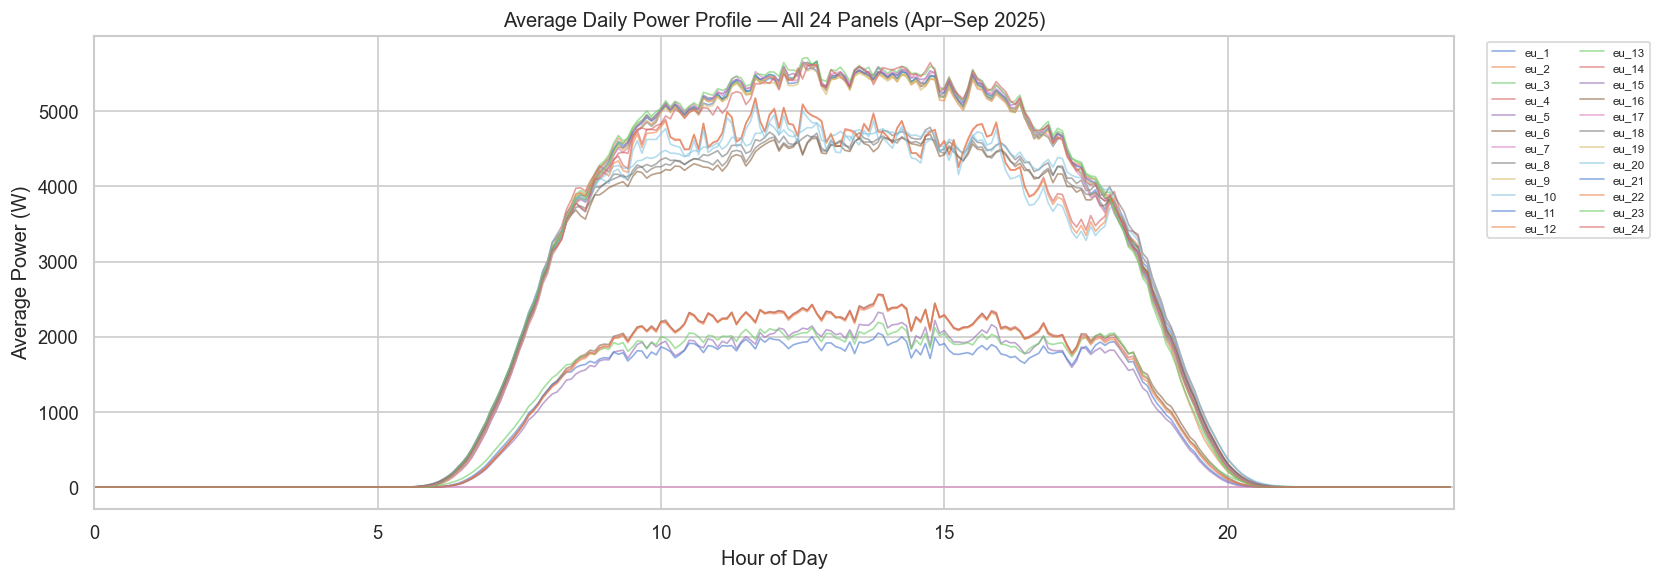

In [4]:
# Extract time features
combined_df["hour"] = combined_df["time"].dt.hour + combined_df["time"].dt.minute / 60
combined_df["date"] = combined_df["time"].dt.date
combined_df["month"] = combined_df["time"].dt.to_period("M")

# Average power by time-of-day across the whole dataset
hourly_avg = combined_df.groupby("hour")[eu_cols].mean()

fig, ax = plt.subplots(figsize=(14, 5))
for col in eu_cols:
    ax.plot(hourly_avg.index, hourly_avg[col], alpha=0.6, linewidth=1, label=col)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Power (W)")
ax.set_title("Average Daily Power Profile — All 24 Panels (Apr–Sep 2025)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, ncol=2)
ax.set_xlim(0, 24)
plt.tight_layout()
plt.show()

## 4. Distribution Analysis

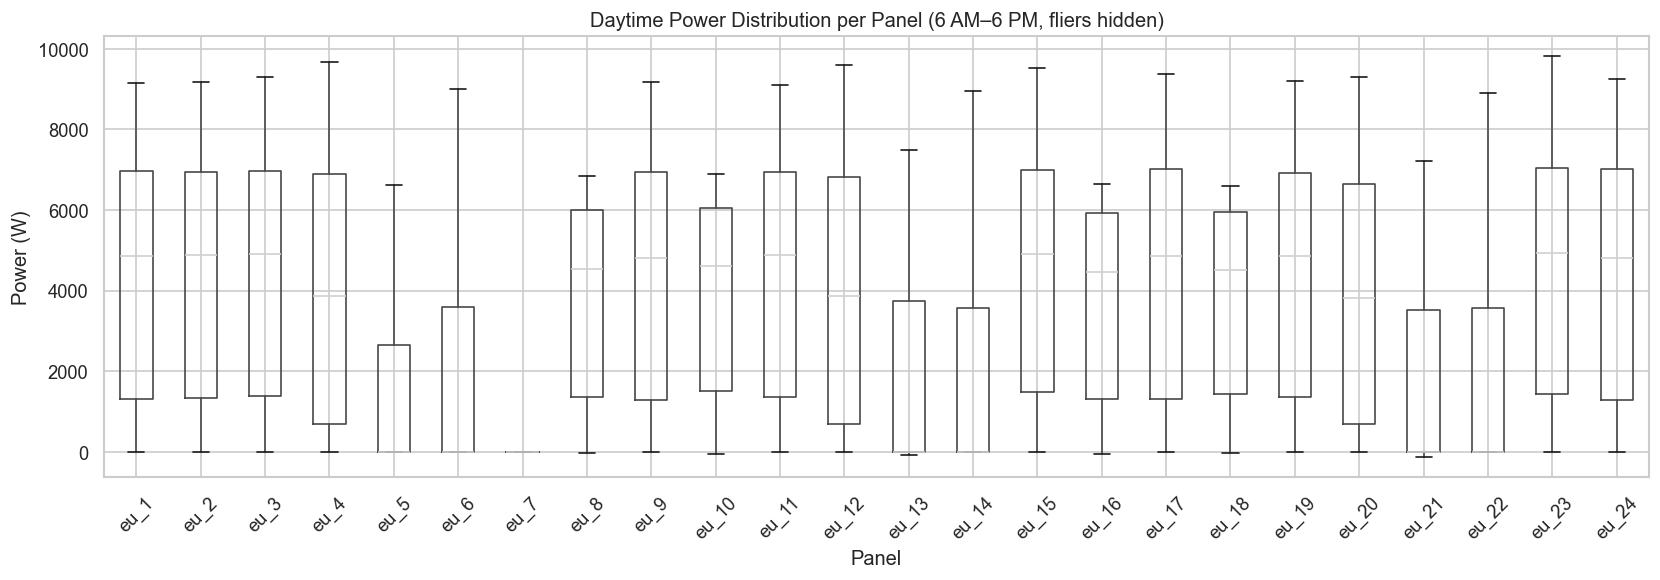

In [28]:
# Box plot of peak-hour power (daytime only: 6 AM–6 PM) per panel
daytime = combined_df[(combined_df["hour"] >= 6) & (combined_df["hour"] <= 18)]

fig, ax = plt.subplots(figsize=(14, 5))
daytime[eu_cols].boxplot(ax=ax, vert=True, showfliers=False)
ax.set_title("Daytime Power Distribution per Panel (6 AM–6 PM, fliers hidden)")
ax.set_ylabel("Power (W)")
ax.set_xlabel("Panel")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

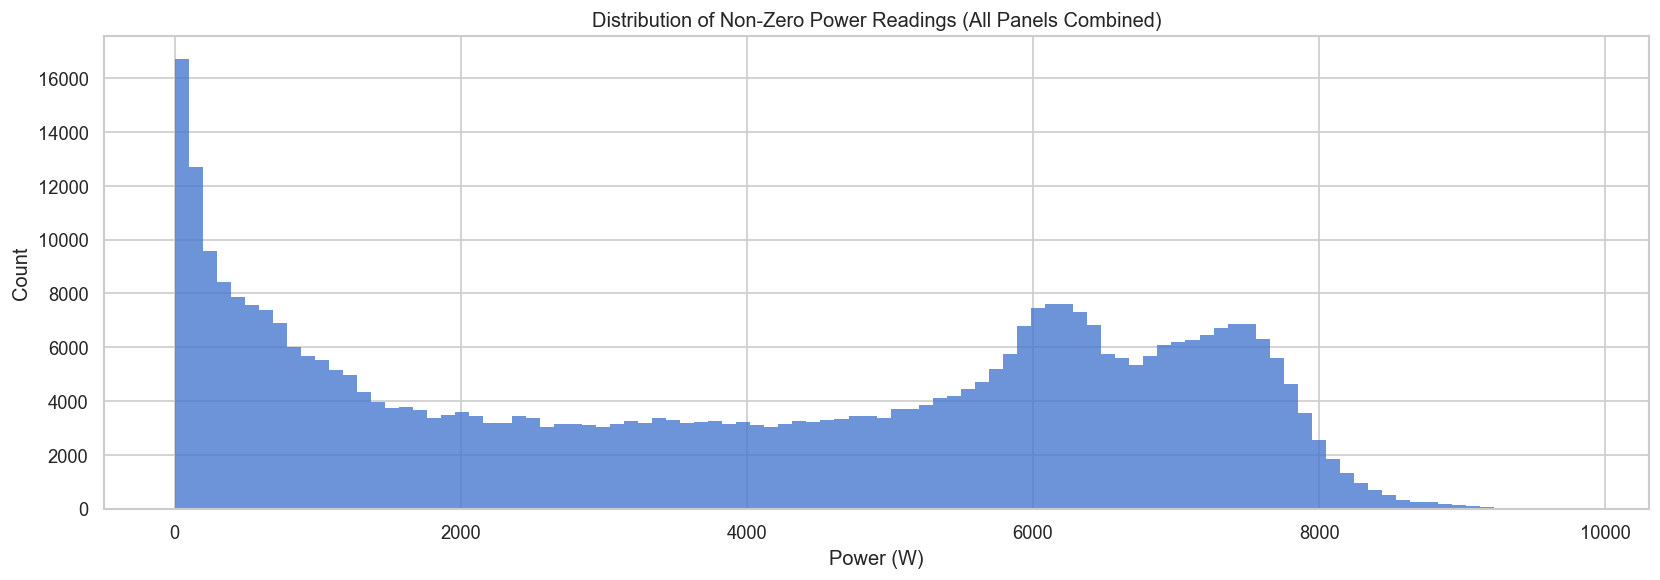

Non-zero readings: 411,512 / 905,472 (45.4%)


In [6]:
# Histogram of non-zero power values (all panels stacked)
non_zero = combined_df[eu_cols].values.flatten()
non_zero = non_zero[non_zero > 0]

fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(non_zero, bins=100, edgecolor="none", alpha=0.8)
ax.set_title("Distribution of Non-Zero Power Readings (All Panels Combined)")
ax.set_xlabel("Power (W)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(f"Non-zero readings: {len(non_zero):,} / {combined_df[eu_cols].size:,} "
      f"({len(non_zero)/combined_df[eu_cols].size*100:.1f}%)")

## 5. Monthly Trends

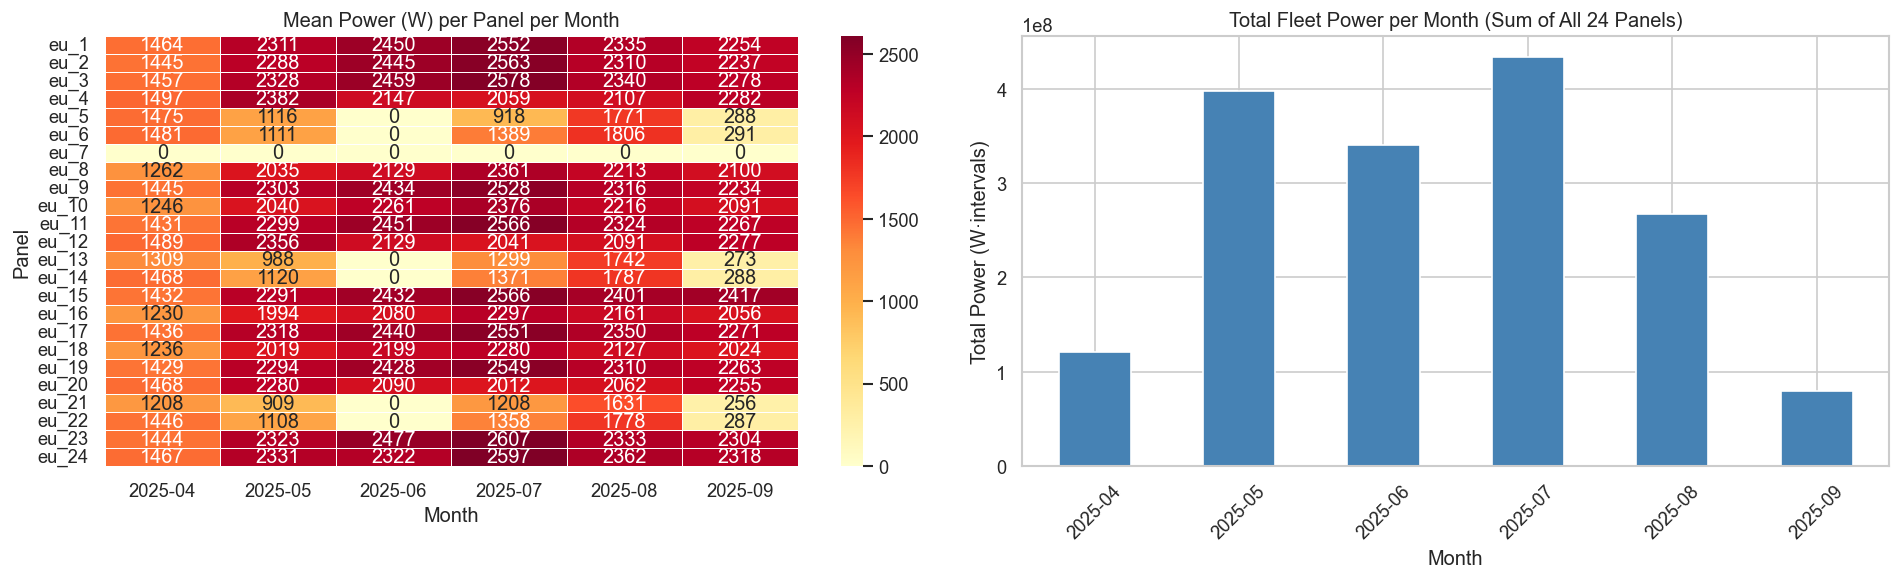

In [7]:
# Total energy per panel per month (sum of 5-min power readings → proxy for energy)
combined_df["total_power"] = combined_df[eu_cols].sum(axis=1)

monthly_total = combined_df.groupby("month")[eu_cols].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Mean power per panel per month (heatmap)
monthly_mean = combined_df.groupby("month")[eu_cols].mean()
sns.heatmap(monthly_mean.T, annot=True, fmt=".0f", cmap="YlOrRd", ax=axes[0],
            linewidths=0.5)
axes[0].set_title("Mean Power (W) per Panel per Month")
axes[0].set_ylabel("Panel")
axes[0].set_xlabel("Month")

# Total fleet power per month (bar chart)
fleet_monthly = combined_df.groupby("month")["total_power"].sum()
fleet_monthly.plot(kind="bar", ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("Total Fleet Power per Month (Sum of All 24 Panels)")
axes[1].set_ylabel("Total Power (W·intervals)")
axes[1].set_xlabel("Month")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

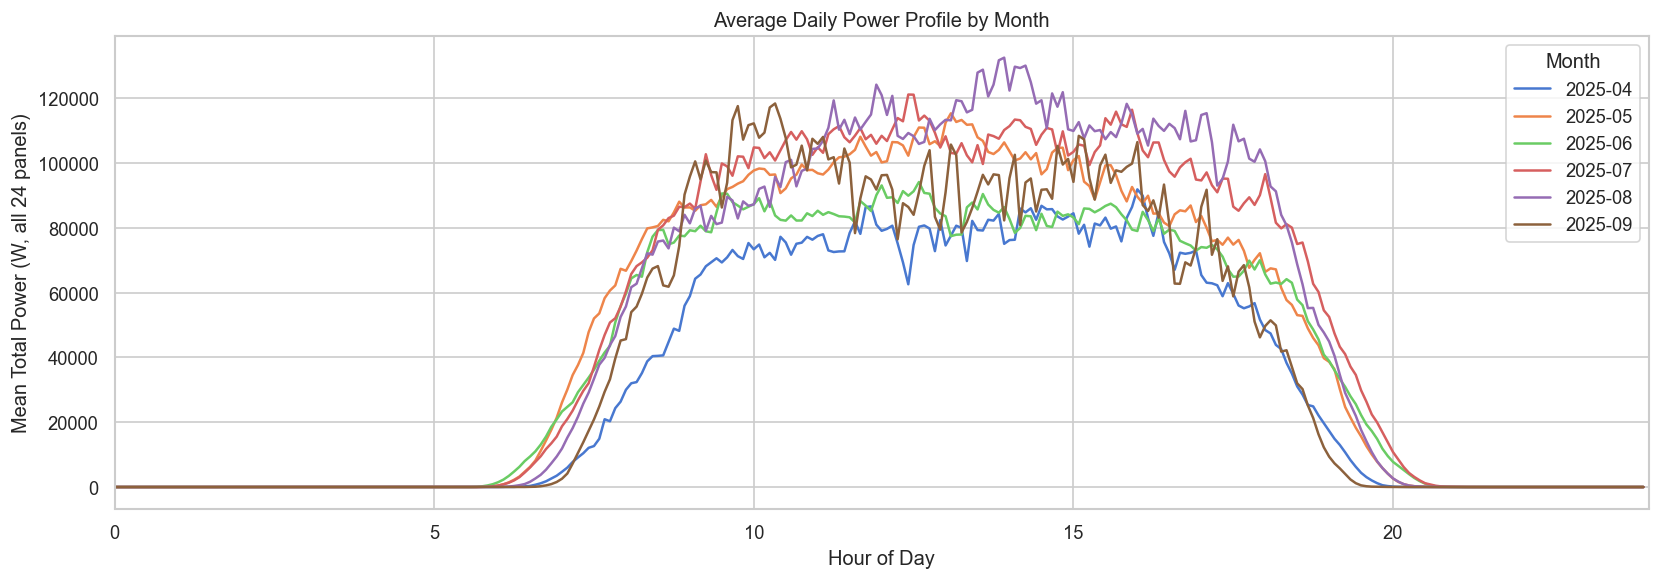

In [8]:
# Average daily profile by month (fleet average across all panels)
combined_df["month_str"] = combined_df["time"].dt.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(14, 5))
for label, grp in combined_df.groupby("month_str"):
    profile = grp.groupby("hour")["total_power"].mean()
    ax.plot(profile.index, profile.values, label=label, linewidth=1.5)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Mean Total Power (W, all 24 panels)")
ax.set_title("Average Daily Power Profile by Month")
ax.legend(title="Month")
ax.set_xlim(0, 24)
plt.tight_layout()
plt.show()

## 6. Panel-to-Panel Correlation

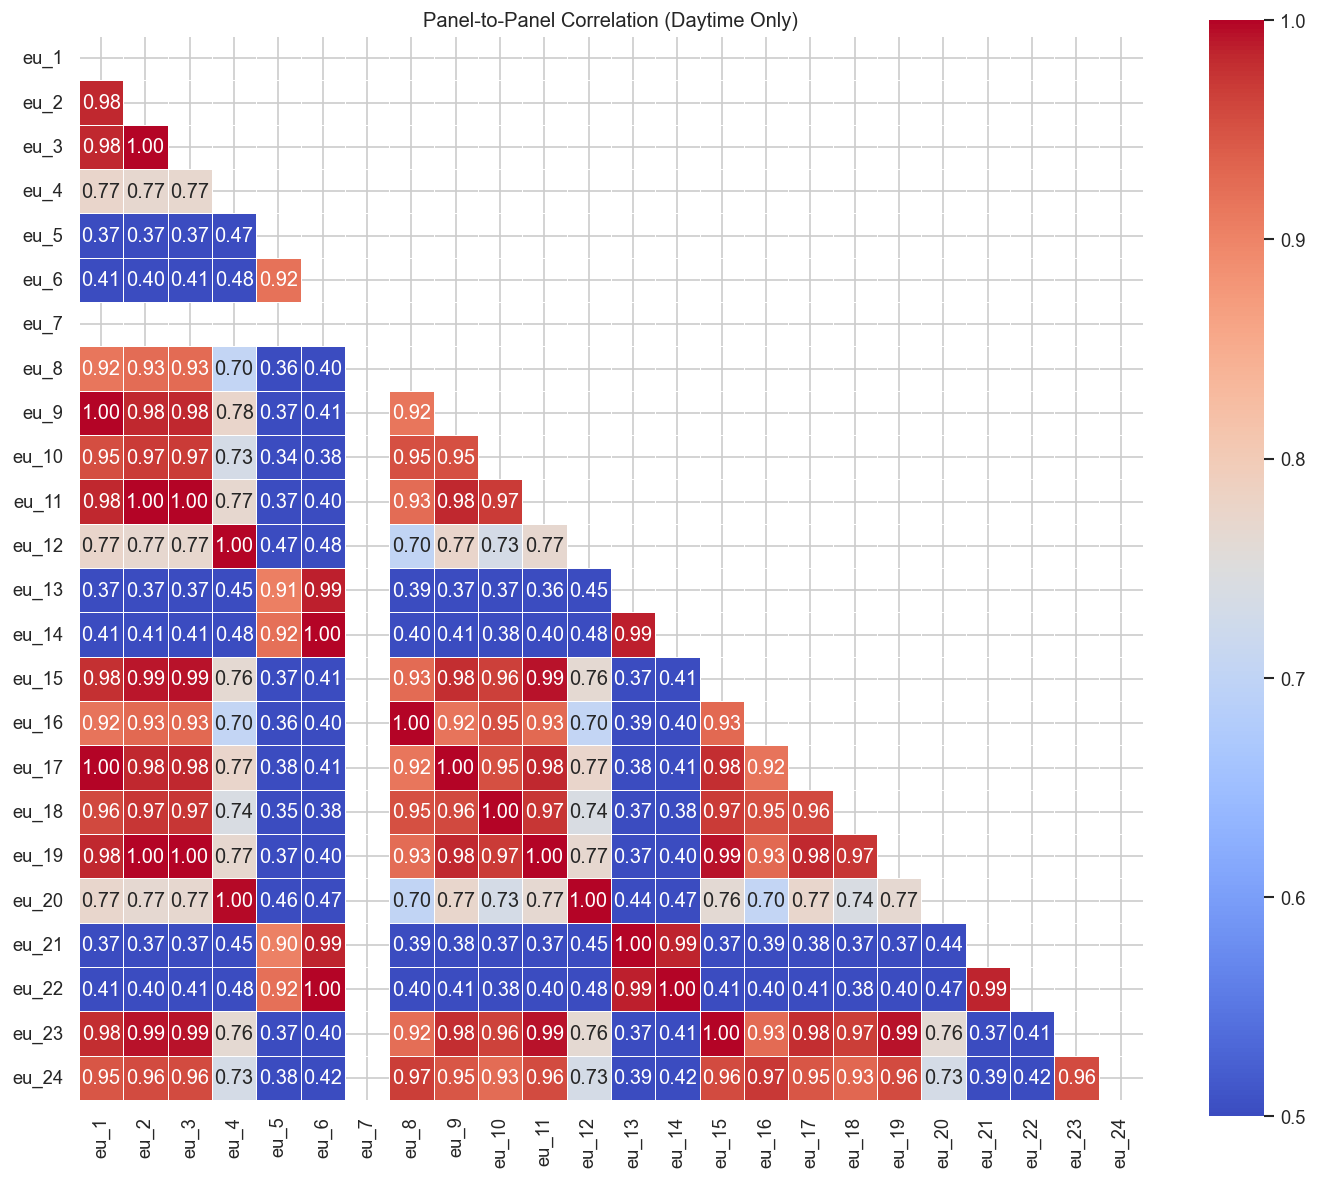

Panel pairs with correlation < 0.85 (possible shading / orientation difference):
panel_a panel_b     corr
  eu_10    eu_5 0.340735
  eu_18    eu_5 0.346120
  eu_16    eu_5 0.359905
   eu_8    eu_5 0.361441
  eu_13   eu_11 0.364752
  eu_19   eu_13 0.365159
  eu_13   eu_10 0.365724
  eu_11    eu_5 0.366017
  eu_19    eu_5 0.366543
  eu_13    eu_2 0.367089
  eu_18   eu_13 0.367229
  eu_23   eu_13 0.367369
   eu_5    eu_2 0.368266
  eu_21   eu_11 0.368342
  eu_13    eu_3 0.368395
  eu_23    eu_5 0.368609
  eu_21   eu_19 0.368763
  eu_13    eu_1 0.369421
   eu_5    eu_1 0.369500
   eu_5    eu_3 0.369989
  eu_21    eu_2 0.370581
  eu_23   eu_21 0.370989
  eu_15   eu_13 0.371360
  eu_21   eu_10 0.371526
  eu_21    eu_3 0.371851
  eu_13    eu_9 0.372225
  eu_21    eu_1 0.372963
  eu_21   eu_18 0.373084
  eu_15    eu_5 0.373175
   eu_9    eu_5 0.374011
  eu_21   eu_15 0.374915
  eu_17   eu_13 0.375075
  eu_17    eu_5 0.375431
  eu_21    eu_9 0.375741
  eu_21   eu_17 0.378709
  eu_14   eu_10 0.3

In [9]:
# Pearson correlation heatmap (daytime only to avoid trivial night-time zeros)
corr = daytime[eu_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=0.5, vmax=1.0, ax=ax, linewidths=0.3, square=True)
ax.set_title("Panel-to-Panel Correlation (Daytime Only)")
plt.tight_layout()
plt.show()

low_corr_pairs = (corr.where(~mask).stack()
                  .reset_index()
                  .rename(columns={"level_0": "panel_a", "level_1": "panel_b", 0: "corr"})
                  .query("corr < 0.85")
                  .sort_values("corr"))

if len(low_corr_pairs):
    print("Panel pairs with correlation < 0.85 (possible shading / orientation difference):")
    print(low_corr_pairs.to_string(index=False))
else:
    print("All panel pairs have correlation ≥ 0.85.")

## 7. Outlier & Anomaly Detection

In [10]:
# Daily energy per panel — flag days with unusually low output
daily_energy = combined_df.groupby("date")[eu_cols].sum()

# Compute z-scores per panel relative to its own mean/std
daily_z = (daily_energy - daily_energy.mean()) / daily_energy.std()

# Days where any panel's z-score < -2.5 (suspiciously low)
anomaly_mask = (daily_z < -2.5).any(axis=1)
anomaly_days = daily_z[anomaly_mask]

print(f"Days with at least one panel z-score < -2.5: {anomaly_mask.sum()} / {len(daily_z)}")
if len(anomaly_days):
    print("\nAnomaly days (panels with z < -2.5 highlighted):")
    for day, row in anomaly_days.iterrows():
        flagged = row[row < -2.5].index.tolist()
        print(f"  {day}  → {', '.join(flagged)}  (z = {row[flagged].round(2).to_dict()})")

Days with at least one panel z-score < -2.5: 3 / 131

Anomaly days (panels with z < -2.5 highlighted):
  2025-04-25  → eu_1, eu_2, eu_3, eu_4, eu_8, eu_9, eu_10, eu_11, eu_12, eu_15, eu_16, eu_17, eu_18, eu_19, eu_20, eu_23, eu_24  (z = {'eu_1': -2.55, 'eu_2': -2.51, 'eu_3': -2.53, 'eu_4': -2.53, 'eu_8': -2.68, 'eu_9': -2.53, 'eu_10': -2.71, 'eu_11': -2.53, 'eu_12': -2.53, 'eu_15': -2.6, 'eu_16': -2.68, 'eu_17': -2.54, 'eu_18': -2.7, 'eu_19': -2.53, 'eu_20': -2.57, 'eu_23': -2.54, 'eu_24': -2.51})
  2025-04-26  → eu_1, eu_2, eu_3, eu_4, eu_8, eu_9, eu_10, eu_11, eu_12, eu_15, eu_16, eu_17, eu_18, eu_19, eu_20, eu_23, eu_24  (z = {'eu_1': -2.55, 'eu_2': -2.51, 'eu_3': -2.53, 'eu_4': -2.53, 'eu_8': -2.68, 'eu_9': -2.53, 'eu_10': -2.71, 'eu_11': -2.53, 'eu_12': -2.53, 'eu_15': -2.6, 'eu_16': -2.68, 'eu_17': -2.54, 'eu_18': -2.7, 'eu_19': -2.53, 'eu_20': -2.57, 'eu_23': -2.54, 'eu_24': -2.51})
  2025-04-27  → eu_1, eu_2, eu_3, eu_4, eu_8, eu_9, eu_10, eu_11, eu_12, eu_15, eu_16, eu_17, eu_

In [11]:
# Negative power readings check
neg_counts = (combined_df[eu_cols] < 0).sum()
if neg_counts.any():
    print("Panels with negative power readings:")
    print(neg_counts[neg_counts > 0])
else:
    print("No negative power readings found.")

# Sudden drops: 5-min-to-5-min diff exceeding panel's 99th-percentile magnitude
diffs = combined_df[eu_cols].diff().abs()
thresholds = diffs.quantile(0.99)

spike_counts = (diffs > thresholds * 3).sum()
print(f"\nTimestamps with extreme 5-min jumps (>3× the 99th-pctl diff) per panel:")
print(spike_counts.to_string())

Panels with negative power readings:
eu_8      3
eu_10     3
eu_13     7
eu_16     5
eu_18     3
eu_21    23
dtype: int64

Timestamps with extreme 5-min jumps (>3× the 99th-pctl diff) per panel:
eu_1     0
eu_2     0
eu_3     0
eu_4     0
eu_5     0
eu_6     0
eu_7     0
eu_8     0
eu_9     0
eu_10    1
eu_11    0
eu_12    0
eu_13    0
eu_14    0
eu_15    0
eu_16    0
eu_17    0
eu_18    1
eu_19    0
eu_20    0
eu_21    0
eu_22    0
eu_23    0
eu_24    0


## 8. Per-Panel Daily Energy Time Series

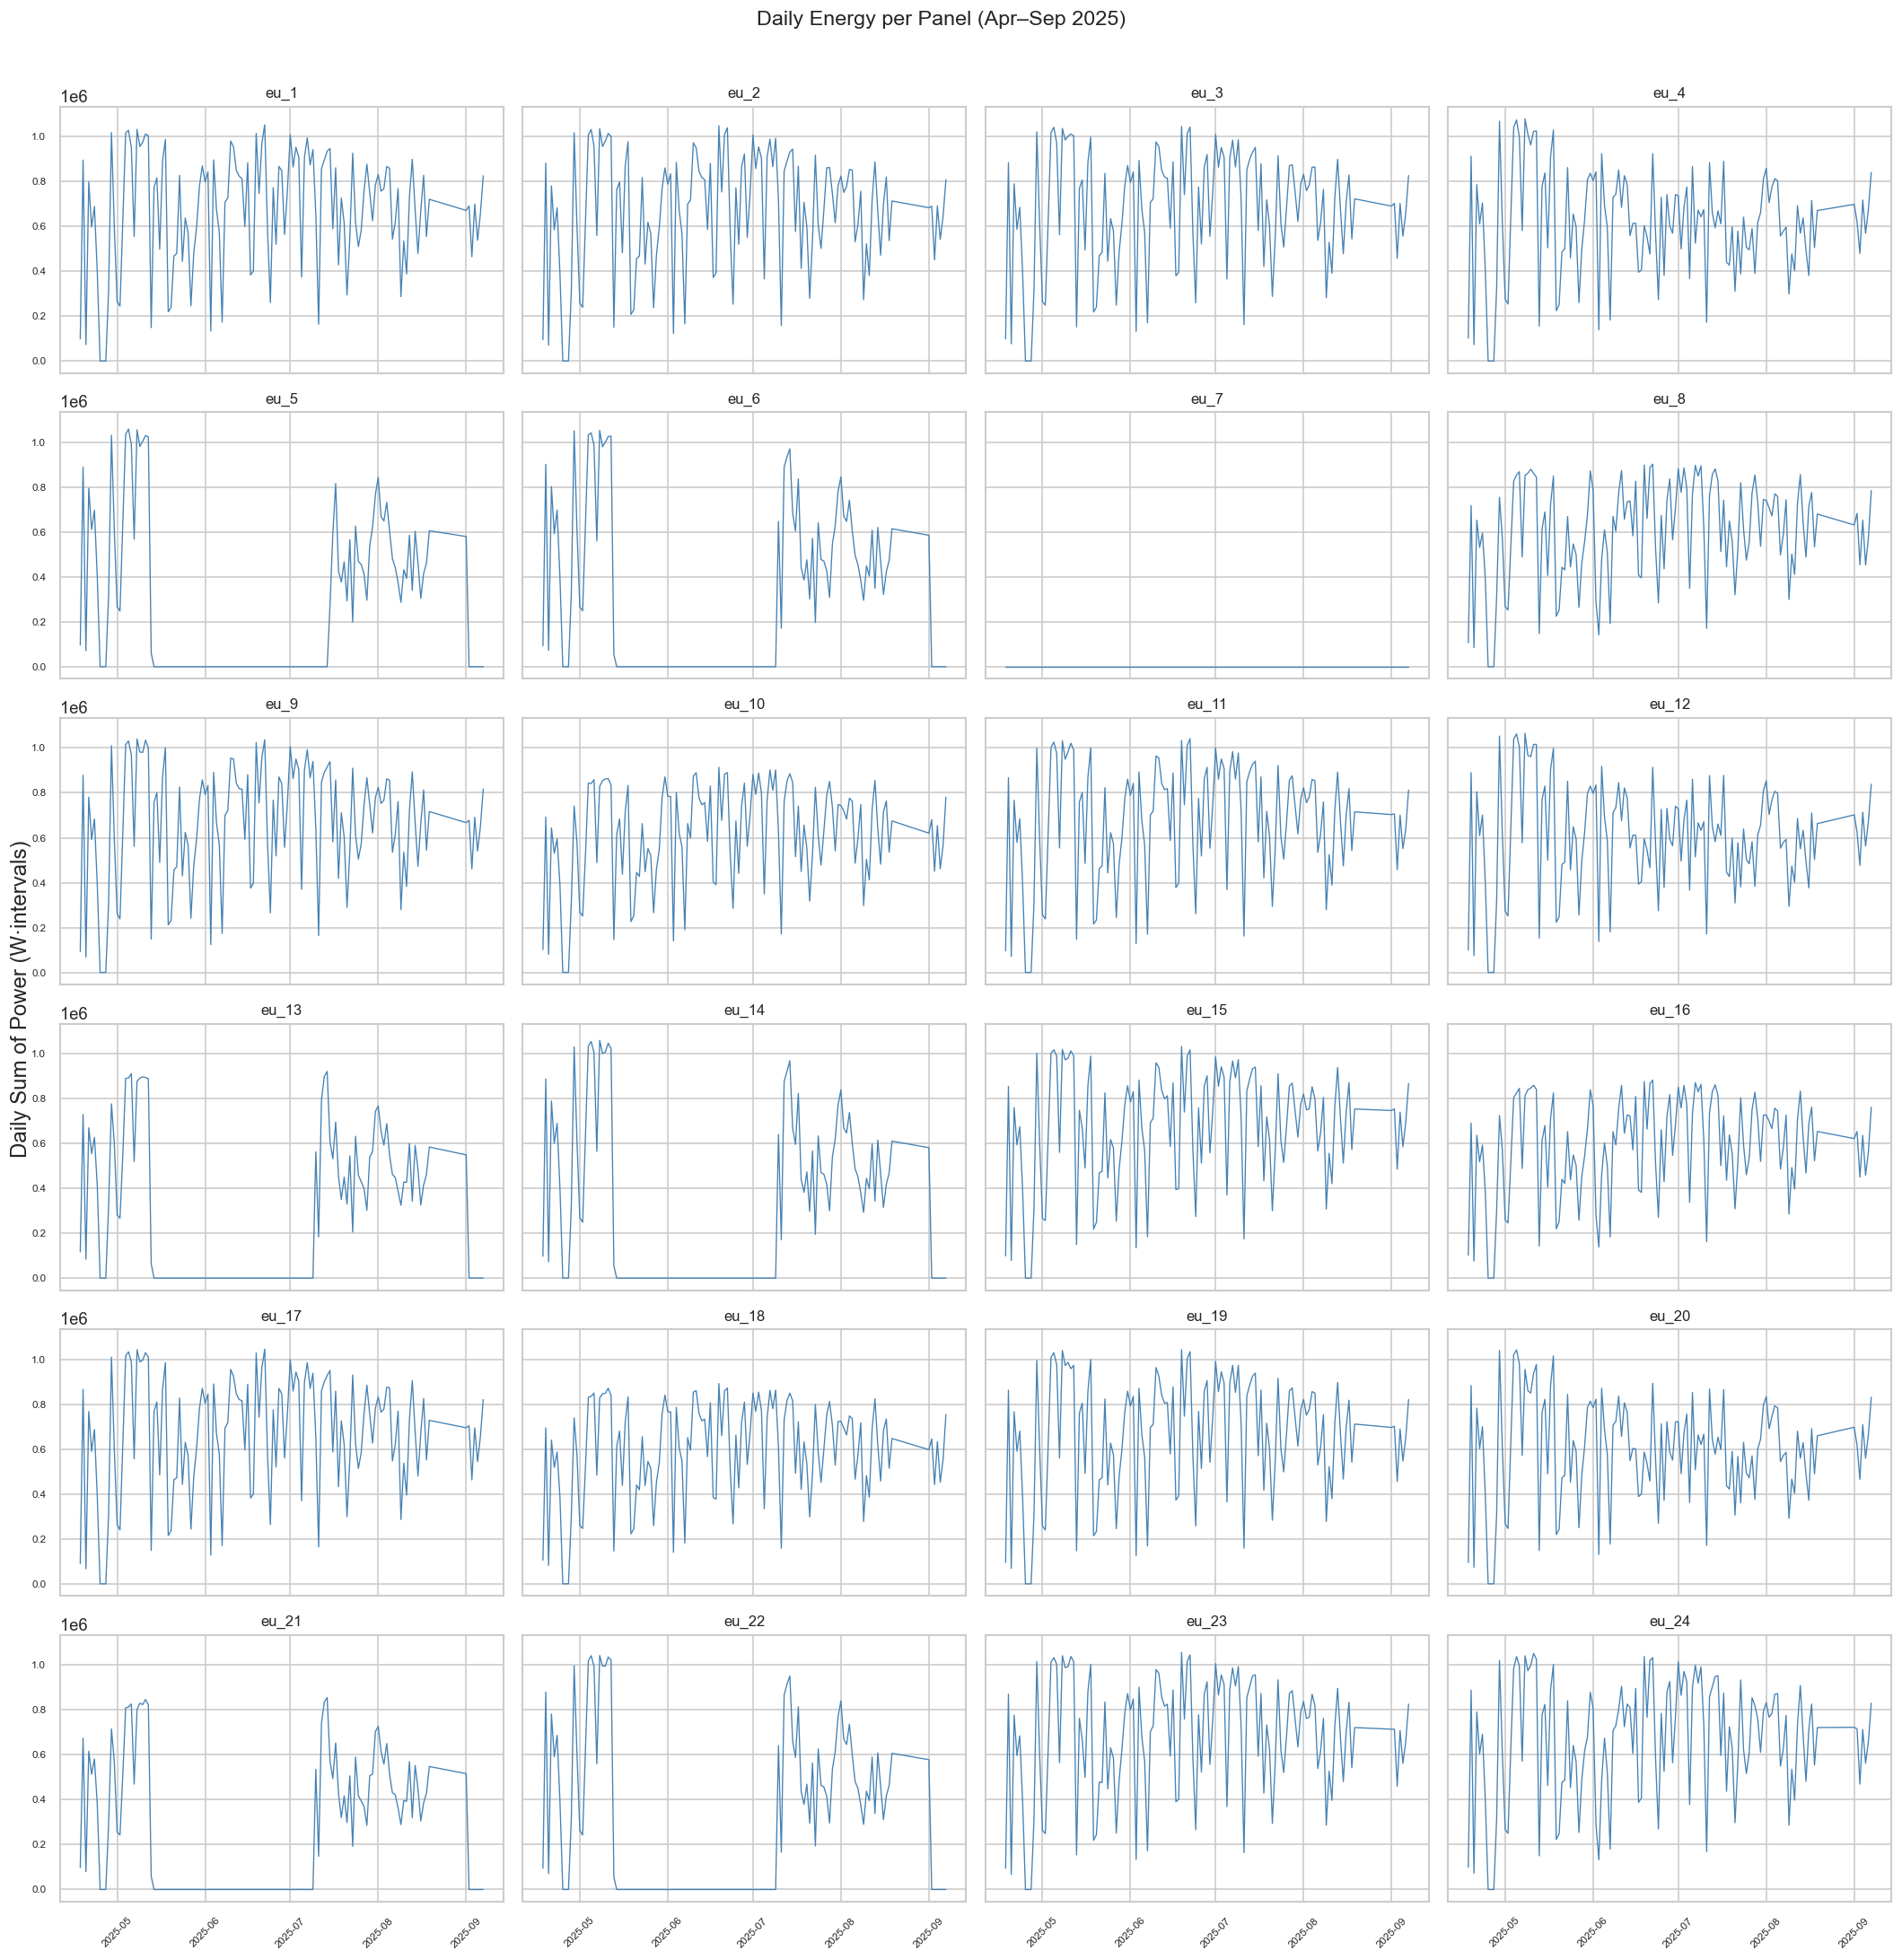

In [12]:
# Daily energy (sum of power × 5 min intervals) per panel
fig, axes = plt.subplots(6, 4, figsize=(18, 18), sharex=True, sharey=True)
axes = axes.flatten()

for i, col in enumerate(eu_cols):
    ax = axes[i]
    ax.plot(daily_energy.index, daily_energy[col], linewidth=0.8, color="steelblue")
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

fig.suptitle("Daily Energy per Panel (Apr–Sep 2025)", fontsize=14, y=1.01)
fig.supylabel("Daily Sum of Power (W·intervals)")
plt.tight_layout()
plt.show()

## 9. Summary & Key Findings

In [13]:
print("=" * 70)
print("EDA SUMMARY — Solar Panel Power Data (Area 1, Apr–Sep 2025)")
print("=" * 70)

n_rows, n_cols = combined_df.shape
date_range = f"{combined_df['time'].min():%Y-%m-%d} to {combined_df['time'].max():%Y-%m-%d}"
n_days = combined_df["date"].nunique()
missing_pct = combined_df[eu_cols].isnull().mean().mean() * 100
zero_pct = (combined_df[eu_cols] == 0).mean().mean() * 100

peak_panel = combined_df[eu_cols].max().idxmax()
peak_val = combined_df[eu_cols].max().max()

mean_per_panel = combined_df[eu_cols].mean()
best_panel = mean_per_panel.idxmax()
worst_panel = mean_per_panel.idxmin()

print(f"  Rows:            {n_rows:,}")
print(f"  Panels:          24 (eu_1 – eu_24)")
print(f"  Date range:      {date_range}  ({n_days} unique days)")
print(f"  Time resolution: 5 minutes")
print(f"  Missing values:  {missing_pct:.2f}%")
print(f"  Zero readings:   {zero_pct:.1f}% (night-time expected)")
print(f"  Peak reading:    {peak_val:,.0f} W  ({peak_panel})")
print(f"  Highest avg:     {best_panel}  ({mean_per_panel[best_panel]:,.1f} W)")
print(f"  Lowest avg:      {worst_panel}  ({mean_per_panel[worst_panel]:,.1f} W)")
print(f"  Anomaly days:    {anomaly_mask.sum()}")
print(f"  Neg readings:    {'Yes' if neg_counts.any() else 'None'}")
print("=" * 70)

EDA SUMMARY — Solar Panel Power Data (Area 1, Apr–Sep 2025)
  Rows:            37,728
  Panels:          24 (eu_1 – eu_24)
  Date range:      2025-04-18 to 2025-09-07  (131 unique days)
  Time resolution: 5 minutes
  Missing values:  0.00%
  Zero readings:   54.5% (night-time expected)
  Peak reading:    9,813 W  (eu_23)
  Highest avg:     eu_23  (2,338.8 W)
  Lowest avg:      eu_7  (0.0 W)
  Anomaly days:    3
  Neg readings:    Yes


---
# Performance Benchmarking — Crop Effect on Solar Panel Output
Agrivoltaics study: 7 crop types + control, Performance Ratio analysis normalized by site irradiance.

## B1. Panel Metadata & Crop Group Mapping

In [14]:
panel_meta = pd.DataFrame([
    ("eu_1",  "Strawberry",  False, False, None),
    ("eu_2",  "Broccoli",    False, False, None),
    ("eu_3",  "Pepper",      False, False, None),
    ("eu_4",  "Polli mix 1", False, False, None),
    ("eu_5",  "Control",     True,  False, None),
    ("eu_6",  "Squash",      True,  False, None),
    ("eu_7",  "Polli mix 2", True,  False, None),
    ("eu_8",  "Raspberry",   False, True,  "eu_16"),
    ("eu_9",  "Broccoli",    False, False, None),
    ("eu_10", "Squash",      False, True,  "eu_18"),
    ("eu_11", "Strawberry",  False, False, None),
    ("eu_12", "Polli mix 1", False, False, None),
    ("eu_13", "Polli mix 2", True,  True,  "eu_21"),
    ("eu_14", "Pepper",      True,  False, None),
    ("eu_15", "Control",     False, False, None),
    ("eu_16", "Raspberry",   False, True,  "eu_8"),
    ("eu_17", "Control",     False, False, None),
    ("eu_18", "Squash",      False, True,  "eu_10"),
    ("eu_19", "Pepper",      False, False, None),
    ("eu_20", "Raspberry",   False, False, None),
    ("eu_21", "Polli mix 2", True,  True,  "eu_13"),
    ("eu_22", "Broccoli",    True,  False, None),
    ("eu_23", "Polli mix 1", False, False, None),
    ("eu_24", "Strawberry",  False, False, None),
], columns=["panel", "crop_group", "has_technical_issue", "shared_mppt", "mppt_partner"])

panel_meta["usable"] = ~panel_meta["has_technical_issue"]

print("Panel metadata:")
print(panel_meta.to_string(index=False))

print(f"\nUsable panels: {panel_meta['usable'].sum()} / {len(panel_meta)}")
print(f"\nUsable panels per crop group:")
usable = panel_meta[panel_meta["usable"]]
for grp, sub in usable.groupby("crop_group"):
    dedicated = sub[~sub["shared_mppt"]]["panel"].tolist()
    shared = sub[sub["shared_mppt"]]["panel"].tolist()
    parts = []
    if dedicated:
        parts.append(f"dedicated: {', '.join(dedicated)}")
    if shared:
        parts.append(f"shared MPPT: {', '.join(shared)}")
    print(f"  {grp:15s} → {' | '.join(parts)}")

Panel metadata:
panel  crop_group  has_technical_issue  shared_mppt mppt_partner  usable
 eu_1  Strawberry                False        False         None    True
 eu_2    Broccoli                False        False         None    True
 eu_3      Pepper                False        False         None    True
 eu_4 Polli mix 1                False        False         None    True
 eu_5     Control                 True        False         None   False
 eu_6      Squash                 True        False         None   False
 eu_7 Polli mix 2                 True        False         None   False
 eu_8   Raspberry                False         True        eu_16    True
 eu_9    Broccoli                False        False         None    True
eu_10      Squash                False         True        eu_18    True
eu_11  Strawberry                False        False         None    True
eu_12 Polli mix 1                False        False         None    True
eu_13 Polli mix 2                 T

## B2. Irradiance Data — Load, Clean & Merge

In [15]:
irr_path = base_dir / "all_data" / "data" / "raw" / "irradiance-from-site.csv"
irr_df = pd.read_csv(irr_path, parse_dates=["Site Time"])
irr_df.rename(columns={
    "Site Time": "time",
    "Irradiance - top": "irr_top",
    "Irradiance - bottom": "irr_bottom",
}, inplace=True)

# Clamp negative irradiance to 0 (sensor noise)
irr_df["irr_top"] = irr_df["irr_top"].clip(lower=0)
irr_df["irr_bottom"] = irr_df["irr_bottom"].clip(lower=0)

print(f"Irradiance data: {irr_df.shape[0]:,} rows")
print(f"Date range: {irr_df['time'].min()} → {irr_df['time'].max()}")
print(f"\nIrradiance top  — mean: {irr_df['irr_top'].mean():.1f}, max: {irr_df['irr_top'].max():.1f} W/m²")
print(f"Irradiance bot  — mean: {irr_df['irr_bottom'].mean():.1f}, max: {irr_df['irr_bottom'].max():.1f} W/m²")

# Merge with power data on timestamp
df = combined_df.merge(irr_df, on="time", how="inner")
print(f"\nMerged dataset: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Date range after merge: {df['time'].min()} → {df['time'].max()}")
df.head()

Irradiance data: 56,736 rows
Date range: 2025-04-18 00:00:00 → 2025-10-31 23:55:00

Irradiance top  — mean: 286.8, max: 1302.0 W/m²
Irradiance bot  — mean: 36.1, max: 417.0 W/m²

Merged dataset: 37,728 rows × 32 cols
Date range after merge: 2025-04-18 00:00:00 → 2025-09-07 23:55:00


,time,eu_1,eu_2,eu_3,eu_4,eu_5,eu_6,eu_7,eu_8,eu_9,...,eu_22,eu_23,eu_24,hour,date,month,total_power,month_str,irr_top,irr_bottom
0,2025-04-18 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,2025-04-18,2025-04,0.0,2025-04,0.0,0.0
1,2025-04-18 00:05:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.083333,2025-04-18,2025-04,0.0,2025-04,0.0,0.0
2,2025-04-18 00:10:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.166667,2025-04-18,2025-04,0.0,2025-04,0.0,0.0
3,2025-04-18 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.250000,2025-04-18,2025-04,0.0,2025-04,0.0,0.0
4,2025-04-18 00:20:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.333333,2025-04-18,2025-04,0.0,2025-04,0.0,0.0


## B3. Outlier Cleaning & Performance Ratio Computation

In [16]:
# Usable panels only
usable_panels = panel_meta.loc[panel_meta["usable"], "panel"].tolist()

# Step 1: Replace zeros with NaN (zeros = no usable data)
for col in eu_cols:
    df.loc[df[col] == 0, col] = np.nan

# Step 2: Clamp negative power to NaN
for col in eu_cols:
    df.loc[df[col] < 0, col] = np.nan

# Step 3: IQR-based outlier removal per usable panel (daytime only: irr > 50)
daytime_mask = df["irr_top"] > 50
outlier_report = {}

for col in usable_panels:
    day_vals = df.loc[daytime_mask, col].dropna()
    if len(day_vals) == 0:
        continue
    q1 = day_vals.quantile(0.25)
    q3 = day_vals.quantile(0.75)
    iqr = q3 - q1
    upper_fence = q3 + 3 * iqr
    n_outliers = (df[col] > upper_fence).sum()
    df.loc[df[col] > upper_fence, col] = np.nan
    outlier_report[col] = {"Q1": q1, "Q3": q3, "IQR": iqr, "upper_fence": upper_fence, "n_outliers": n_outliers}

outlier_df = pd.DataFrame(outlier_report).T
print("Outlier detection (IQR × 3 upper fence) — usable panels only:")
print(outlier_df.to_string())

# Step 4: Filter to irradiance > 50 W/m² for PR calculation (IEC 61724 standard)
df_day = df[df["irr_top"] > 50].copy()

# Step 5: Compute simplified PR = power / irradiance_top for each usable panel
pr_cols = []
for col in usable_panels:
    pr_col = f"pr_{col}"
    df_day[pr_col] = df_day[col] / df_day["irr_top"]
    pr_cols.append(pr_col)

print(f"\nDaytime rows (irr > 50 W/m²): {len(df_day):,}")
print(f"PR columns created: {len(pr_cols)}")

# Add time features
df_day["date"] = df_day["time"].dt.date
df_day["week"] = df_day["time"].dt.isocalendar().week.astype(int)
df_day["month_str"] = df_day["time"].dt.strftime("%Y-%m")
df_day["hour"] = df_day["time"].dt.hour + df_day["time"].dt.minute / 60

# Valid (non-NaN) daytime readings per panel after cleaning
valid_counts = df_day[usable_panels].notna().sum().sort_values(ascending=False)
print(f"\nTotal daytime rows (irr > 50): {len(df_day):,}\n")
print("Valid readings per panel after cleaning:")
for panel, count in valid_counts.items():
    pct = count / len(df_day) * 100
    print(f"  {panel:8s}: {count:>6,} / {len(df_day):,}  ({pct:.1f}%)")

Outlier detection (IQR × 3 upper fence) — usable panels only:
                Q1           Q3          IQR   upper_fence  n_outliers
eu_1   2293.315975  6982.935575  4689.619600  21051.794375         0.0
eu_2   2186.119225  6963.776400  4777.657175  21296.747925         0.0
eu_3   2306.692622  6989.890000  4683.197379  21039.482135         0.0
eu_4   2162.793075  7031.992550  4869.199475  21639.590975         0.0
eu_8   2402.730300  6039.115500  3636.385200  16948.271100         0.0
eu_9   2251.830475  6963.868425  4712.037950  21099.982275         0.0
eu_10  2440.944000  6060.069000  3619.125000  16917.444000         0.0
eu_11  2270.180750  6958.664750  4688.484000  21024.116750         0.0
eu_12  2140.195050  6975.409500  4835.214450  21481.052850         0.0
eu_15  2351.466800  7008.682600  4657.215800  20980.330000         0.0
eu_16  2322.801800  5949.933000  3627.131200  16831.326600         0.0
eu_17  2281.587750  7022.827575  4741.239825  21246.547050         0.0
eu_18  2331.167

## B4. Overall Performance Ratio by Crop Group

In [17]:
# Compute daily median PR per usable panel, then aggregate by crop group
daily_pr = df_day.groupby("date")[pr_cols].median()

# Build summary: one row per panel, then group
panel_summary = []
for _, row in panel_meta[panel_meta["usable"]].iterrows():
    p = row["panel"]
    pr_col = f"pr_{p}"
    if pr_col not in daily_pr.columns:
        continue
    vals = daily_pr[pr_col].dropna()
    panel_summary.append({
        "panel": p,
        "crop_group": row["crop_group"],
        "shared_mppt": row["shared_mppt"],
        "median_pr": vals.median(),
        "mean_pr": vals.mean(),
        "std_pr": vals.std(),
        "n_days": len(vals),
    })

panel_summary_df = pd.DataFrame(panel_summary)

# Control group median PR (dedicated MPPT only) as baseline
control_panels = panel_summary_df[
    (panel_summary_df["crop_group"] == "Control") & (~panel_summary_df["shared_mppt"])
]
control_median_pr = control_panels["median_pr"].mean()

panel_summary_df["pct_of_control"] = (panel_summary_df["median_pr"] / control_median_pr * 100).round(1)

# Group-level summary (split dedicated vs shared MPPT)
def group_agg(sub):
    return pd.Series({
        "panels": ", ".join(sub["panel"]),
        "n_panels": len(sub),
        "median_pr": sub["median_pr"].median(),
        "mean_pr": sub["mean_pr"].mean(),
        "std_pr": sub["std_pr"].mean(),
        "pct_of_control": (sub["median_pr"].median() / control_median_pr * 100).round(1),
    })

# Dedicated MPPT groups
dedicated = panel_summary_df[~panel_summary_df["shared_mppt"]]
group_dedicated = dedicated.groupby("crop_group").apply(group_agg).reset_index()
group_dedicated["mppt_type"] = "dedicated"

# Shared MPPT groups
shared = panel_summary_df[panel_summary_df["shared_mppt"]]
if len(shared) > 0:
    group_shared = shared.groupby("crop_group").apply(group_agg).reset_index()
    group_shared["mppt_type"] = "shared"
    group_table = pd.concat([group_dedicated, group_shared], ignore_index=True)
else:
    group_table = group_dedicated

group_table = group_table.sort_values(["mppt_type", "pct_of_control"], ascending=[True, False])

print("=== Performance Ratio Summary by Crop Group ===\n")
print(group_table[["crop_group", "mppt_type", "panels", "n_panels",
                    "median_pr", "mean_pr", "std_pr", "pct_of_control"]].to_string(index=False))
print(f"\nControl baseline median PR: {control_median_pr:.4f}")

=== Performance Ratio Summary by Crop Group ===

 crop_group mppt_type             panels  n_panels  median_pr  mean_pr   std_pr  pct_of_control
Polli mix 1 dedicated eu_4, eu_12, eu_23         3   7.939674 8.022414 0.548338           102.1
  Raspberry dedicated              eu_20         1   7.782652 7.914110 0.562056           100.1
    Control dedicated       eu_15, eu_17         2   7.778169 7.851718 0.569591           100.0
 Strawberry dedicated eu_1, eu_11, eu_24         3   7.754156 7.840545 0.543137            99.7
     Pepper dedicated        eu_3, eu_19         2   7.673282 7.766738 0.523143            98.7
   Broccoli dedicated         eu_2, eu_9         2   7.651444 7.734755 0.479933            98.4
  Raspberry    shared        eu_8, eu_16         2   7.466965 7.516174 1.130125            96.0
     Squash    shared       eu_10, eu_18         2   7.396403 7.448595 1.210541            95.1

Control baseline median PR: 7.7782


C:\Users\nhphuong\AppData\Local\Temp\ipykernel_93684\3268800105.py:45: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_dedicated = dedicated.groupby("crop_group").apply(group_agg).reset_index()
C:\Users\nhphuong\AppData\Local\Temp\ipykernel_93684\3268800105.py:51: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_shared = shared.groupby("crop_group").apply(group_agg).reset_index()


C:\Users\nhphuong\AppData\Local\Temp\ipykernel_93684\760176790.py:44: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\nhphuong\Desktop\Solar\all_data\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


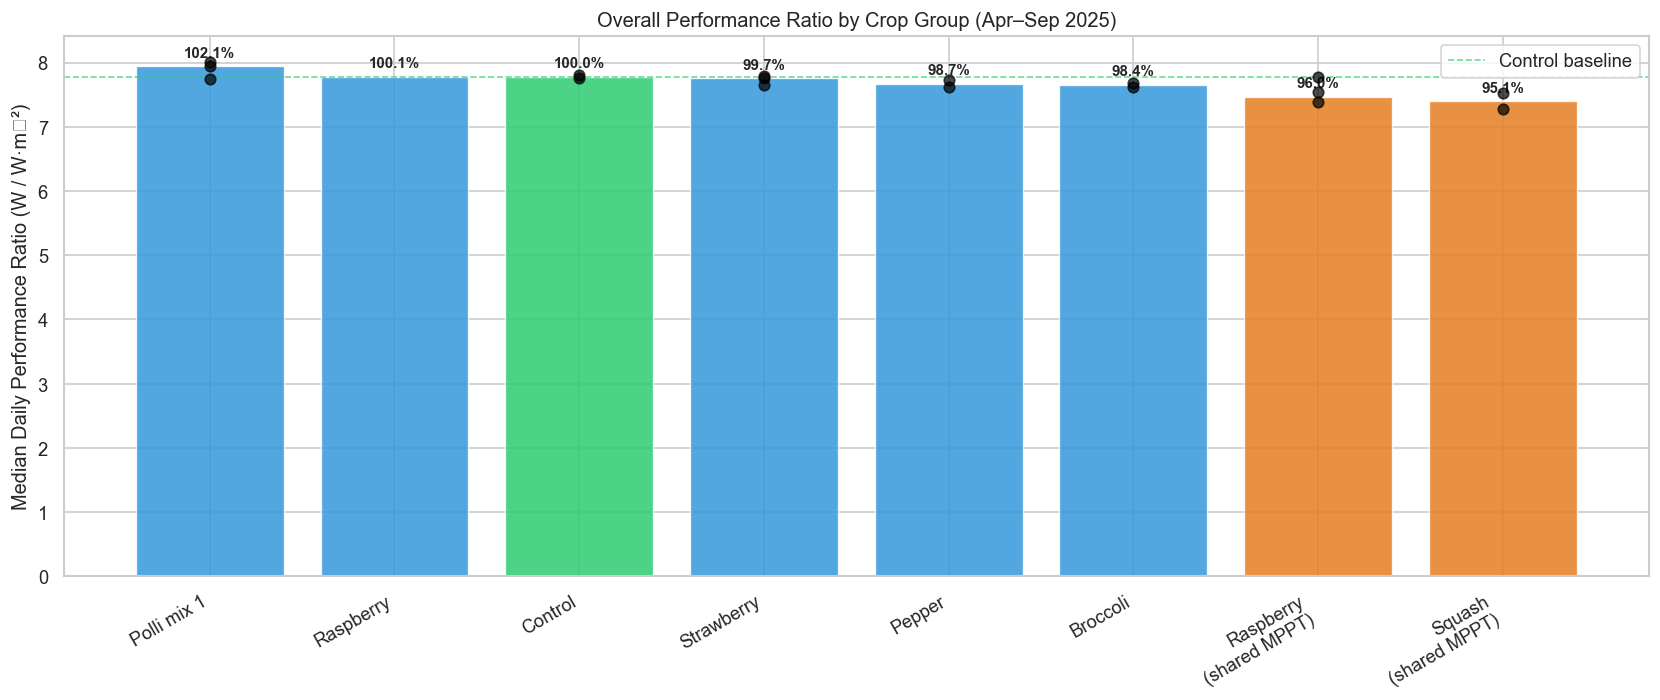

In [18]:
# Bar chart: median PR per crop group with individual panel markers
fig, ax = plt.subplots(figsize=(14, 6))

# Dedicated MPPT groups first
ded_groups = group_table[group_table["mppt_type"] == "dedicated"].sort_values("pct_of_control", ascending=False)
shared_groups = group_table[group_table["mppt_type"] == "shared"].sort_values("pct_of_control", ascending=False)
plot_order = list(ded_groups["crop_group"]) + [g + "\n(shared MPPT)" for g in shared_groups["crop_group"]]
plot_vals = list(ded_groups["median_pr"]) + list(shared_groups["median_pr"])

colors = ["#2ecc71" if g == "Control" else "#3498db" for g in ded_groups["crop_group"]]
colors += ["#e67e22"] * len(shared_groups)

bars = ax.bar(range(len(plot_order)), plot_vals, color=colors, edgecolor="white", linewidth=0.8, alpha=0.85)

# Overlay individual panel dots
x_map = {}
for i, g in enumerate(ded_groups["crop_group"]):
    x_map[g] = ("dedicated", i)
for i, g in enumerate(shared_groups["crop_group"]):
    x_map[g] = ("shared", len(ded_groups) + i)

for _, row in panel_summary_df.iterrows():
    key = row["crop_group"]
    mppt_type = "shared" if row["shared_mppt"] else "dedicated"
    if key in x_map and x_map[key][0] == mppt_type:
        x_pos = x_map[key][1]
    elif key in x_map:
        x_pos = x_map[key][1]
    else:
        continue
    ax.scatter(x_pos, row["median_pr"], color="black", s=40, zorder=5, alpha=0.7)

# Annotate % of control
for i, (val, pct) in enumerate(zip(plot_vals,
    list(ded_groups["pct_of_control"]) + list(shared_groups["pct_of_control"]))):
    ax.text(i, val + 0.1, f"{pct}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.axhline(control_median_pr, color="#2ecc71", linestyle="--", linewidth=1, alpha=0.7, label="Control baseline")
ax.set_xticks(range(len(plot_order)))
ax.set_xticklabels(plot_order, rotation=30, ha="right")
ax.set_ylabel("Median Daily Performance Ratio (W / W·m⁻²)")
ax.set_title("Overall Performance Ratio by Crop Group (Apr–Sep 2025)")
ax.legend()
plt.tight_layout()
plt.show()

## B5. Statistical Tests (Kruskal-Wallis + Dunn's Post-hoc)

In [19]:
from scipy import stats

# Dedicated-MPPT panels only for fair comparison
ded_panels = panel_meta[(panel_meta["usable"]) & (~panel_meta["shared_mppt"])]

# Collect daily median PR per group (dedicated MPPT only)
group_daily_pr = {}
for grp, sub in ded_panels.groupby("crop_group"):
    pr_series = []
    for p in sub["panel"]:
        pr_col = f"pr_{p}"
        if pr_col in daily_pr.columns:
            pr_series.append(daily_pr[pr_col].dropna())
    if pr_series:
        combined = pd.concat(pr_series)
        group_daily_pr[grp] = combined.values

# Kruskal-Wallis test across all dedicated-MPPT groups
groups_list = list(group_daily_pr.values())
group_names = list(group_daily_pr.keys())

kw_stat, kw_p = stats.kruskal(*groups_list)
print(f"Kruskal-Wallis H-statistic: {kw_stat:.4f}")
print(f"p-value: {kw_p:.6f}")
print(f"Significant at α=0.05: {'Yes' if kw_p < 0.05 else 'No'}\n")

# Dunn's post-hoc with Bonferroni correction
try:
    import scikit_posthocs as sp
    dunn_data = []
    dunn_labels = []
    for name, vals in group_daily_pr.items():
        dunn_data.extend(vals)
        dunn_labels.extend([name] * len(vals))
    dunn_result = sp.posthoc_dunn(dunn_data, dunn_labels, p_adjust="bonferroni")
    print("Dunn's post-hoc pairwise p-values (Bonferroni corrected):")
    print(dunn_result.round(4).to_string())
except ImportError:
    print("scikit-posthocs not installed. Install with: pip install scikit-posthocs")
    print("Falling back to pairwise Mann-Whitney U tests with Bonferroni correction:\n")
    from itertools import combinations
    n_comparisons = len(list(combinations(group_names, 2)))
    print(f"{'Group A':15s} {'Group B':15s} {'U-stat':>10s} {'p-raw':>10s} {'p-corrected':>12s} {'Sig':>5s}")
    print("-" * 70)
    for g1, g2 in combinations(group_names, 2):
        u_stat, p_raw = stats.mannwhitneyu(group_daily_pr[g1], group_daily_pr[g2], alternative="two-sided")
        p_corr = min(p_raw * n_comparisons, 1.0)
        sig = "***" if p_corr < 0.001 else "**" if p_corr < 0.01 else "*" if p_corr < 0.05 else "ns"
        print(f"{g1:15s} {g2:15s} {u_stat:10.1f} {p_raw:10.6f} {p_corr:12.6f} {sig:>5s}")

Kruskal-Wallis H-statistic: 54.0862
p-value: 0.000000
Significant at α=0.05: Yes

scikit-posthocs not installed. Install with: pip install scikit-posthocs
Falling back to pairwise Mann-Whitney U tests with Bonferroni correction:

Group A         Group B             U-stat      p-raw  p-corrected   Sig
----------------------------------------------------------------------
Broccoli        Control            29863.0   0.082696     1.000000    ns
Broccoli        Pepper             32385.0   0.819242     1.000000    ns
Broccoli        Polli mix 1        34760.0   0.000000     0.000000   ***
Broccoli        Raspberry          13606.0   0.006751     0.101267    ns
Broccoli        Strawberry         44551.0   0.044684     0.670259    ns
Control         Pepper             35212.0   0.144335     1.000000    ns
Control         Polli mix 1        39874.0   0.000052     0.000773   ***
Control         Raspberry          15169.0   0.236218     1.000000    ns
Control         Strawberry         49044.0

## B6. Weekly Temporal Trends — PR & % of Control

C:\Users\nhphuong\AppData\Local\Temp\ipykernel_93684\867328422.py:52: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\nhphuong\Desktop\Solar\all_data\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


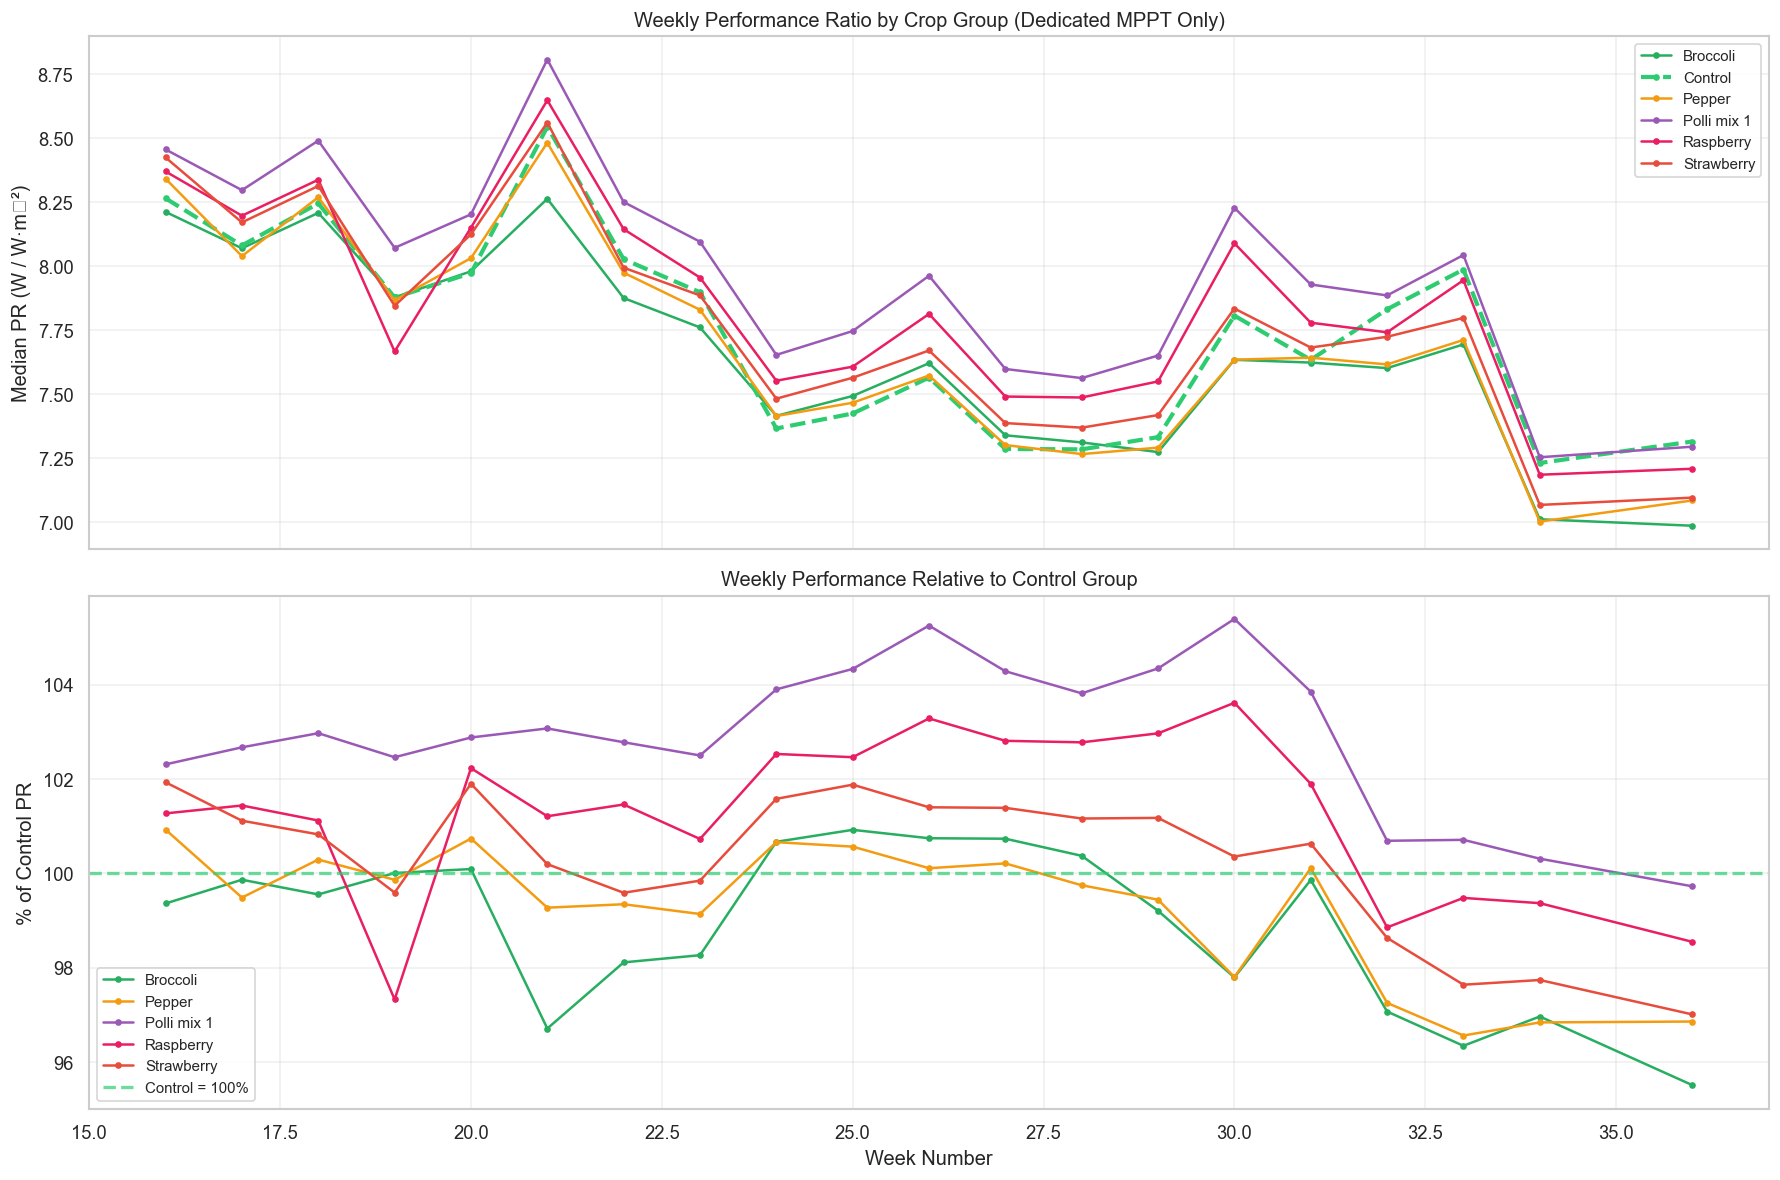

In [20]:
# Weekly median PR per crop group (dedicated MPPT only)
weekly_pr = df_day.groupby("week")[pr_cols].median()

# Compute group-level weekly PR (dedicated MPPT only)
ded_panels_list = panel_meta[(panel_meta["usable"]) & (~panel_meta["shared_mppt"])]

group_weekly = {}
for grp, sub in ded_panels_list.groupby("crop_group"):
    cols = [f"pr_{p}" for p in sub["panel"] if f"pr_{p}" in weekly_pr.columns]
    if cols:
        group_weekly[grp] = weekly_pr[cols].median(axis=1)

group_weekly_df = pd.DataFrame(group_weekly)
weeks = group_weekly_df.index

# Plot 1: Weekly PR trends
crop_colors = {
    "Control": "#2ecc71", "Strawberry": "#e74c3c", "Broccoli": "#27ae60",
    "Pepper": "#f39c12", "Polli mix 1": "#9b59b6", "Raspberry": "#e91e63",
    "Squash": "#3498db",
}

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

for grp in group_weekly_df.columns:
    color = crop_colors.get(grp, "#95a5a6")
    lw = 2.5 if grp == "Control" else 1.5
    ls = "--" if grp == "Control" else "-"
    axes[0].plot(weeks, group_weekly_df[grp], label=grp, color=color, linewidth=lw, linestyle=ls, marker="o", markersize=3)

axes[0].set_ylabel("Median PR (W / W·m⁻²)")
axes[0].set_title("Weekly Performance Ratio by Crop Group (Dedicated MPPT Only)")
axes[0].legend(loc="upper right", fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot 2: Weekly % of control
control_weekly = group_weekly_df["Control"]
for grp in group_weekly_df.columns:
    if grp == "Control":
        continue
    color = crop_colors.get(grp, "#95a5a6")
    pct = group_weekly_df[grp] / control_weekly * 100
    axes[1].plot(weeks, pct, label=grp, color=color, linewidth=1.5, marker="o", markersize=3)

axes[1].axhline(100, color="#2ecc71", linestyle="--", linewidth=2, alpha=0.7, label="Control = 100%")
axes[1].set_xlabel("Week Number")
axes[1].set_ylabel("% of Control PR")
axes[1].set_title("Weekly Performance Relative to Control Group")
axes[1].legend(loc="lower left", fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## B7. Intra-Group Consistency (Individual Panel PR per Group)

C:\Users\nhphuong\AppData\Local\Temp\ipykernel_93684\2533365715.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_dict.values(), labels=data_dict.keys(), patch_artist=True,
C:\Users\nhphuong\AppData\Local\Temp\ipykernel_93684\2533365715.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_dict.values(), labels=data_dict.keys(), patch_artist=True,
C:\Users\nhphuong\AppData\Local\Temp\ipykernel_93684\2533365715.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_dict.values(), labels=data_dict.keys(), patch_artist=True,
C:\Users\nhphuong\AppData\Local\Temp\ipykernel_93

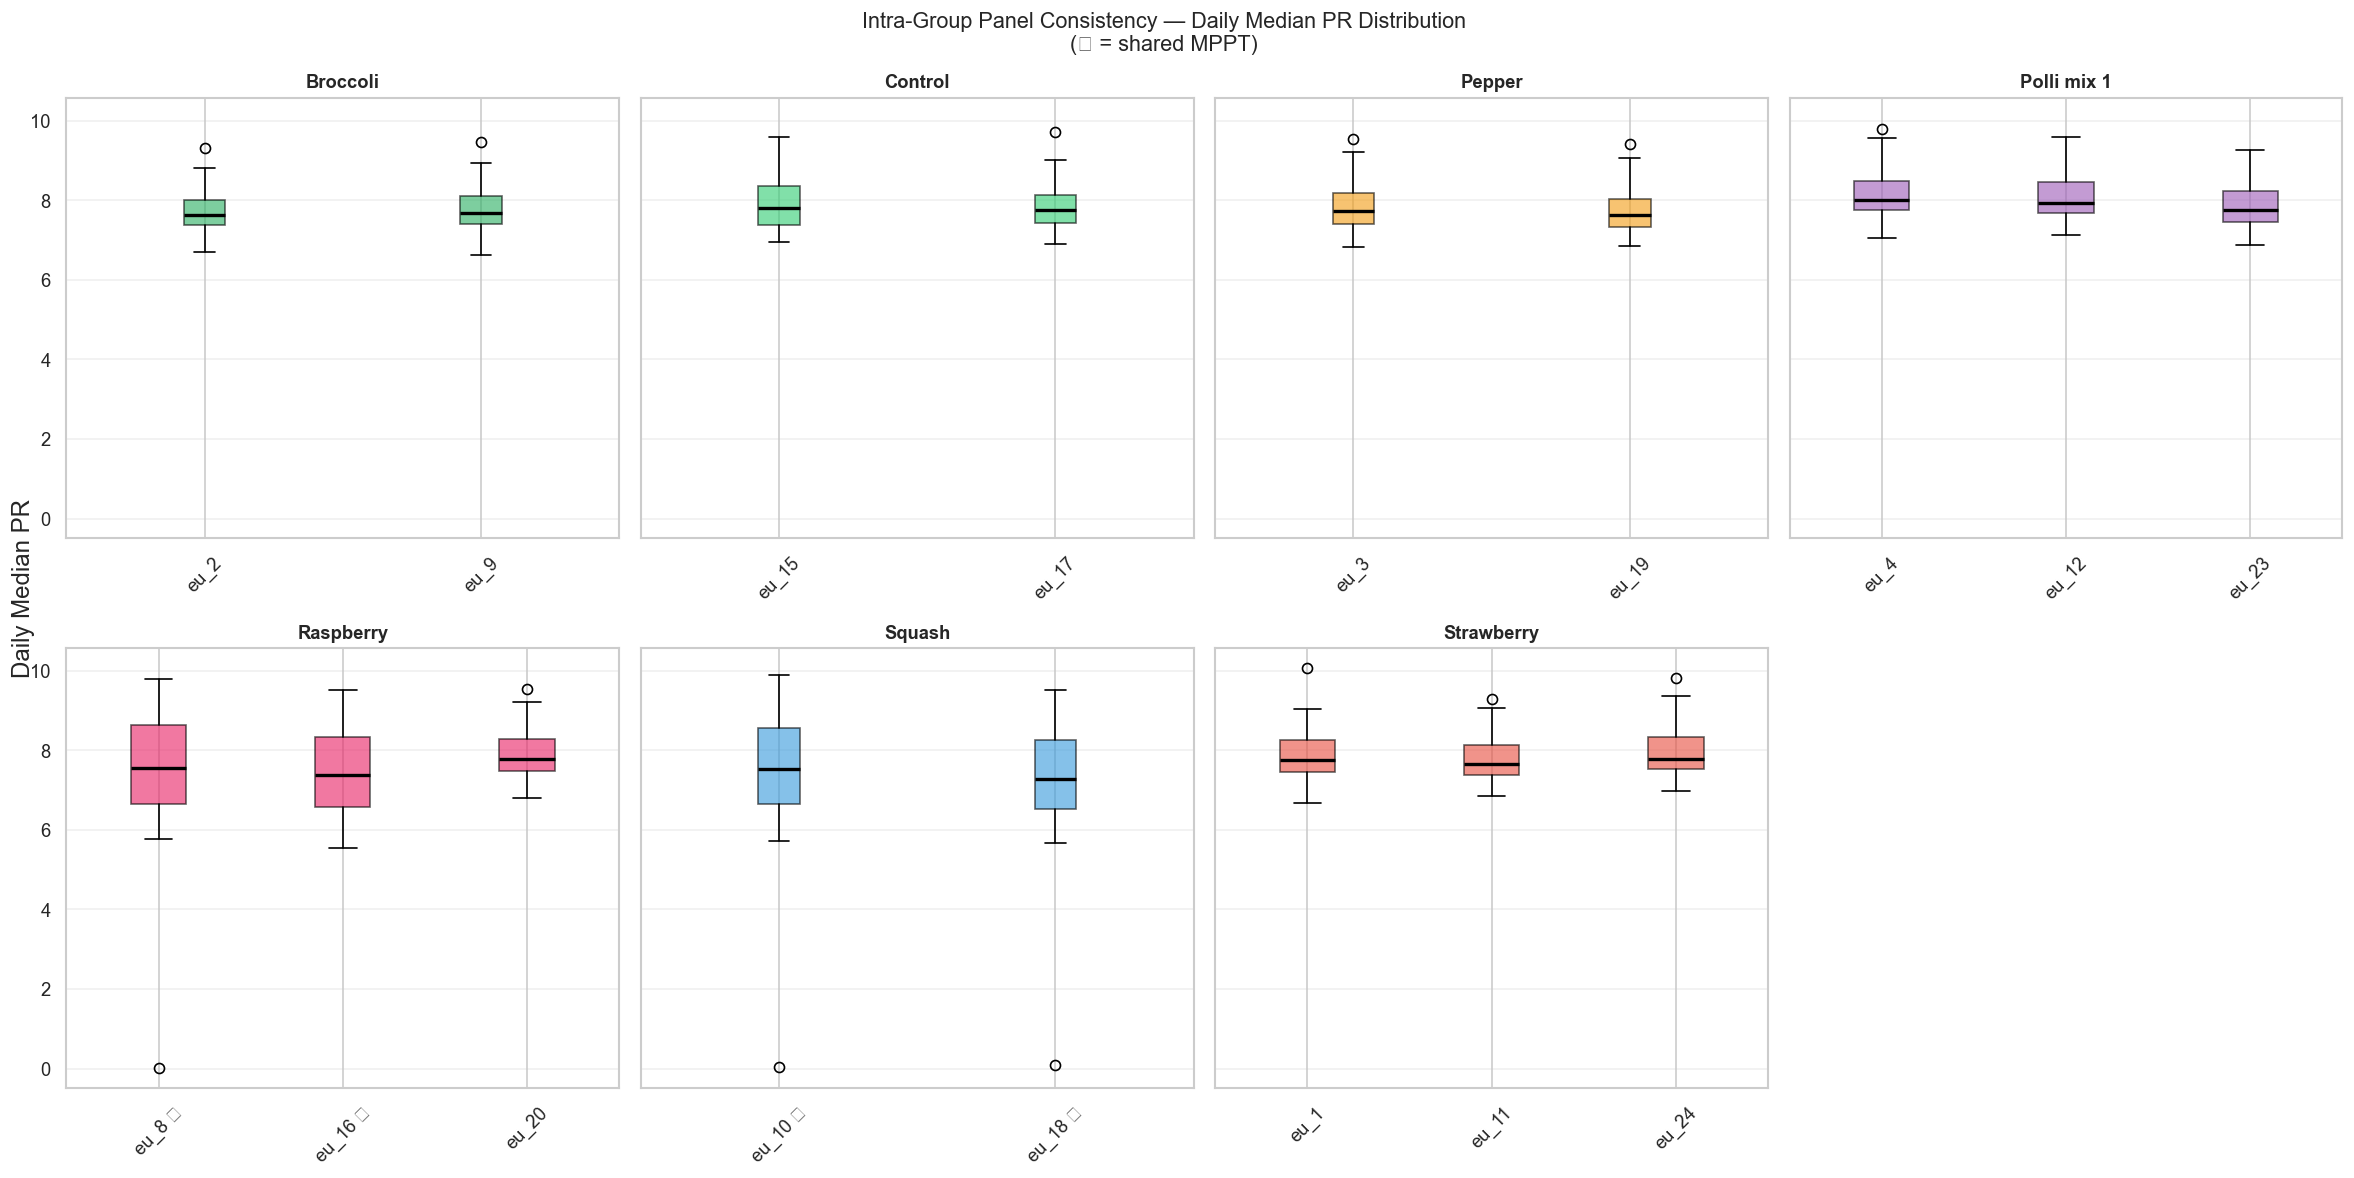

In [21]:
# Box plots of daily median PR per panel, grouped by crop type
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=True)
axes = axes.flatten()

crop_groups_sorted = sorted(panel_meta[panel_meta["usable"]]["crop_group"].unique())

for idx, grp in enumerate(crop_groups_sorted):
    ax = axes[idx]
    sub = panel_meta[(panel_meta["usable"]) & (panel_meta["crop_group"] == grp)]
    data_dict = {}
    for _, row in sub.iterrows():
        p = row["panel"]
        pr_col = f"pr_{p}"
        if pr_col in daily_pr.columns:
            label = p
            if row["shared_mppt"]:
                label += " ⚡"
            data_dict[label] = daily_pr[pr_col].dropna().values

    if data_dict:
        ax.boxplot(data_dict.values(), labels=data_dict.keys(), patch_artist=True,
                   boxprops=dict(facecolor=crop_colors.get(grp, "#95a5a6"), alpha=0.6),
                   medianprops=dict(color="black", linewidth=2))
    ax.set_title(grp, fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.3, axis="y")

# Hide unused subplot
if len(crop_groups_sorted) < len(axes):
    for j in range(len(crop_groups_sorted), len(axes)):
        axes[j].set_visible(False)

fig.suptitle("Intra-Group Panel Consistency — Daily Median PR Distribution\n(⚡ = shared MPPT)", fontsize=13)
fig.supylabel("Daily Median PR")
plt.tight_layout()
plt.show()

## B8. Average Daily Power Profile by Crop Group

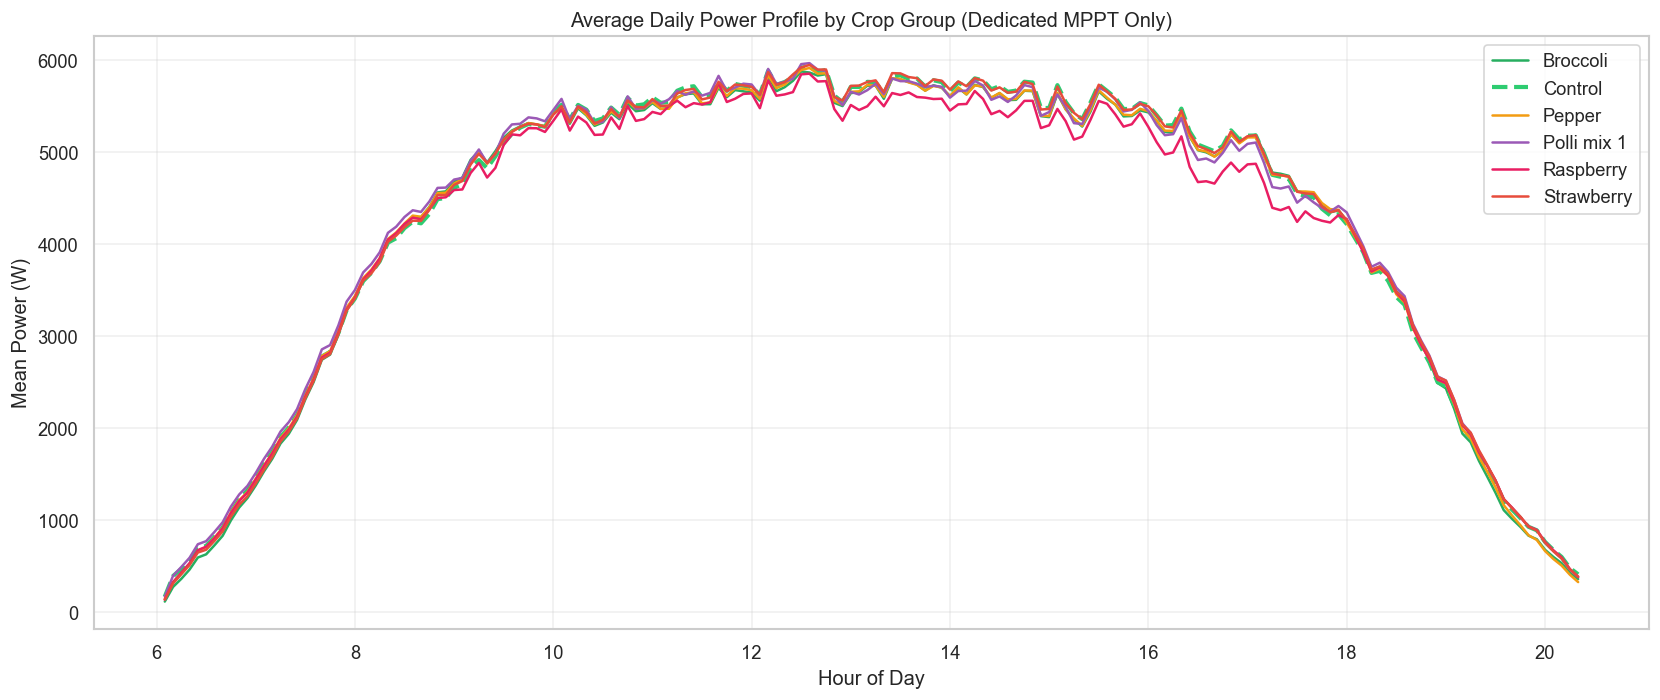

In [22]:
# Average raw power by hour of day for each crop group (dedicated MPPT only)
fig, ax = plt.subplots(figsize=(14, 6))

for grp, sub in ded_panels_list.groupby("crop_group"):
    panel_cols = [p for p in sub["panel"] if p in df_day.columns]
    if not panel_cols:
        continue
    group_mean = df_day.groupby("hour")[panel_cols].mean().mean(axis=1)
    color = crop_colors.get(grp, "#95a5a6")
    lw = 2.5 if grp == "Control" else 1.5
    ls = "--" if grp == "Control" else "-"
    ax.plot(group_mean.index, group_mean.values, label=grp, color=color, linewidth=lw, linestyle=ls)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Mean Power (W)")
ax.set_title("Average Daily Power Profile by Crop Group (Dedicated MPPT Only)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

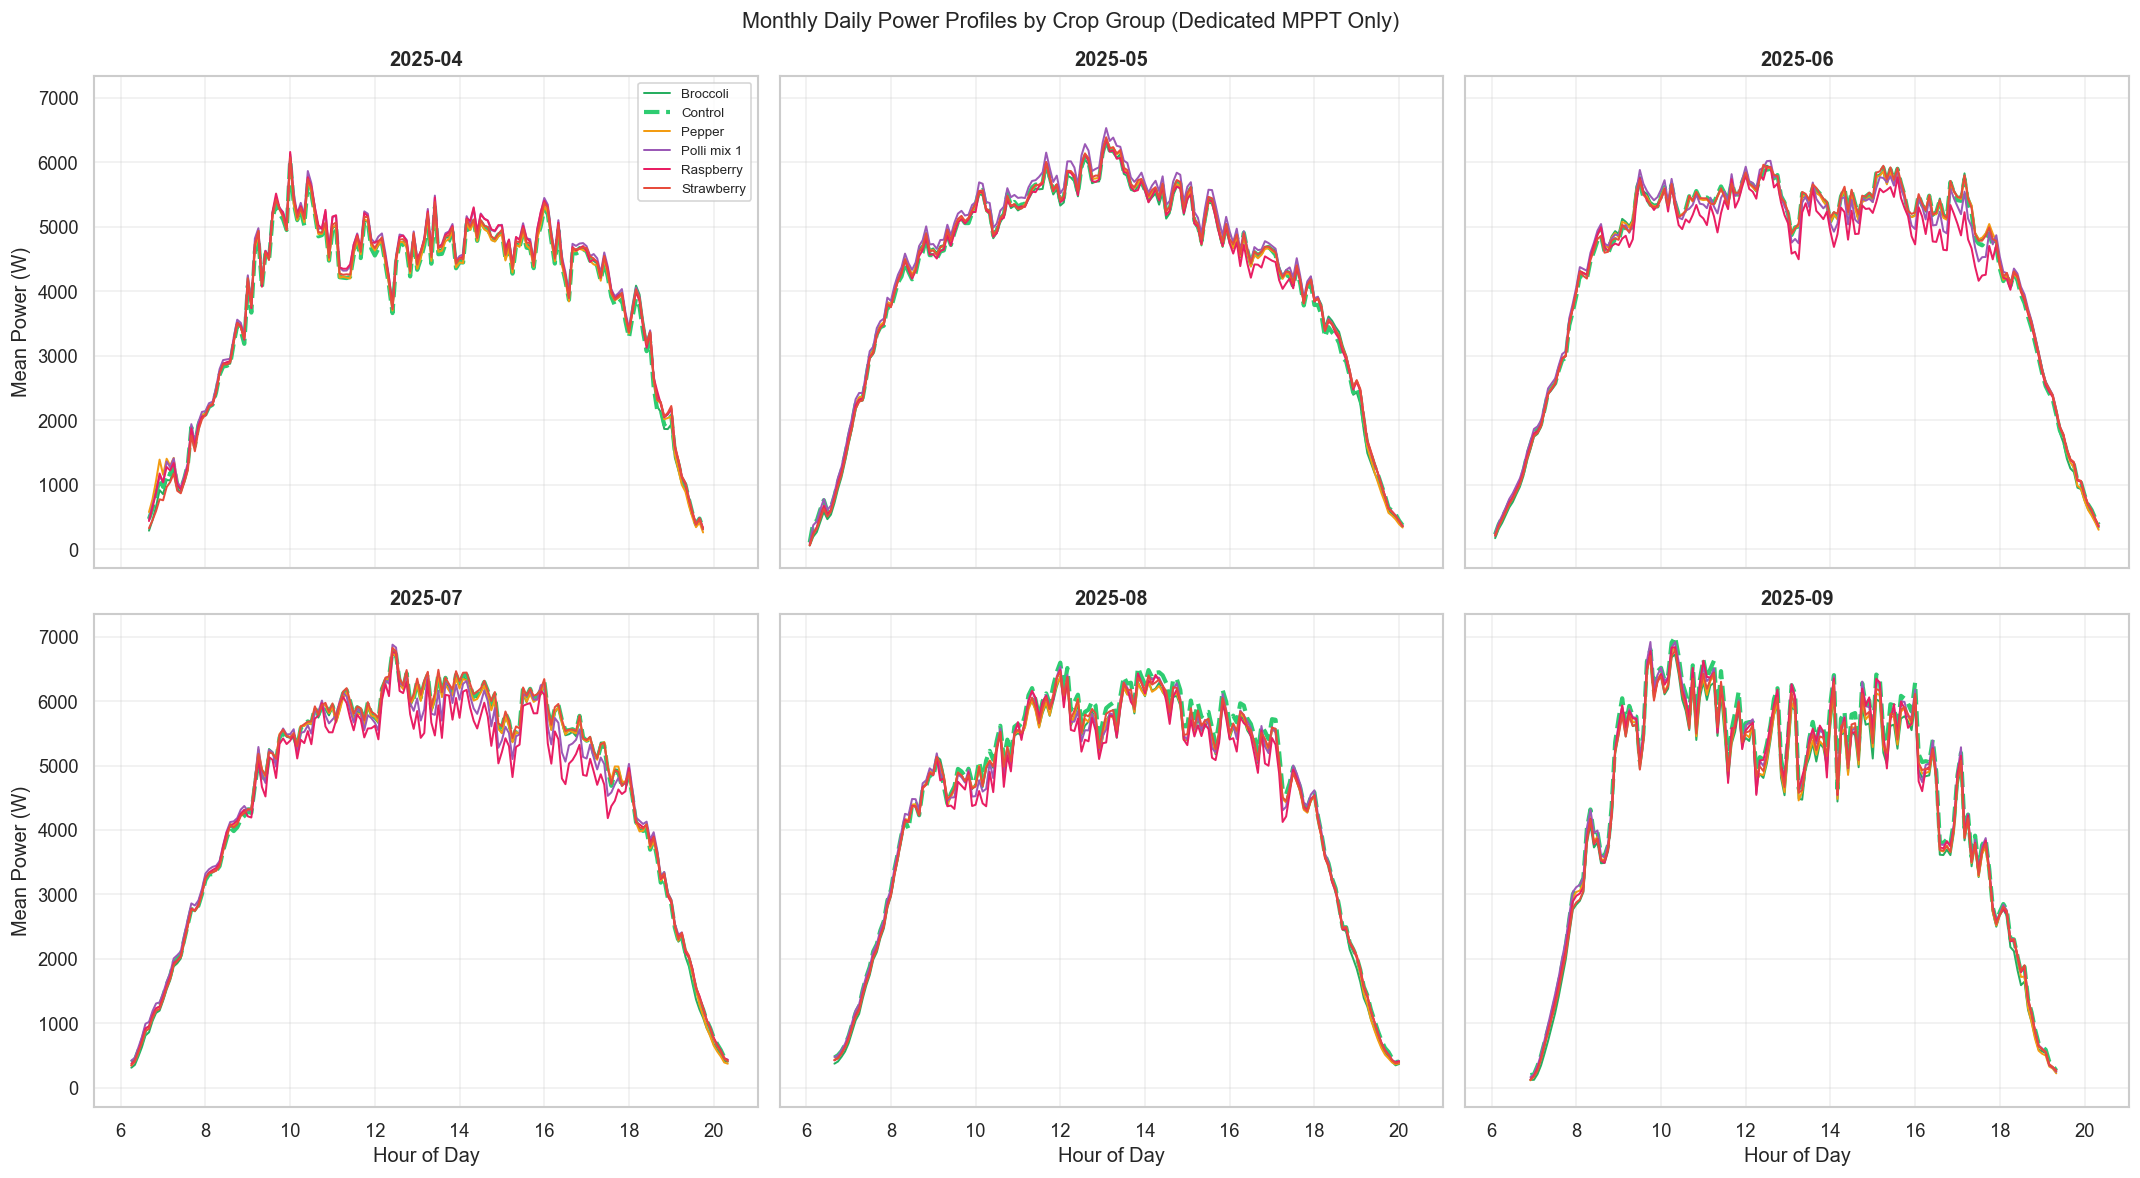

In [23]:
# Monthly daily power profile evolution by crop group (dedicated MPPT only)
months_in_data = sorted(df_day["month_str"].unique())

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True, sharex=True)
axes = axes.flatten()

for idx, month in enumerate(months_in_data):
    if idx >= len(axes):
        break
    ax = axes[idx]
    month_data = df_day[df_day["month_str"] == month]

    for grp, sub in ded_panels_list.groupby("crop_group"):
        panel_cols = [p for p in sub["panel"] if p in month_data.columns]
        if not panel_cols:
            continue
        group_mean = month_data.groupby("hour")[panel_cols].mean().mean(axis=1)
        color = crop_colors.get(grp, "#95a5a6")
        lw = 2.5 if grp == "Control" else 1.2
        ls = "--" if grp == "Control" else "-"
        ax.plot(group_mean.index, group_mean.values, label=grp, color=color, linewidth=lw, linestyle=ls)

    ax.set_title(month, fontweight="bold")
    ax.grid(True, alpha=0.3)
    if idx >= 3:
        ax.set_xlabel("Hour of Day")
    if idx % 3 == 0:
        ax.set_ylabel("Mean Power (W)")

for j in range(len(months_in_data), len(axes)):
    axes[j].set_visible(False)

axes[0].legend(fontsize=8, loc="upper right")
fig.suptitle("Monthly Daily Power Profiles by Crop Group (Dedicated MPPT Only)", fontsize=13)
plt.tight_layout()
plt.show()

## B9. Bottom/Top Irradiance Ratio (Light Beneath Panels)

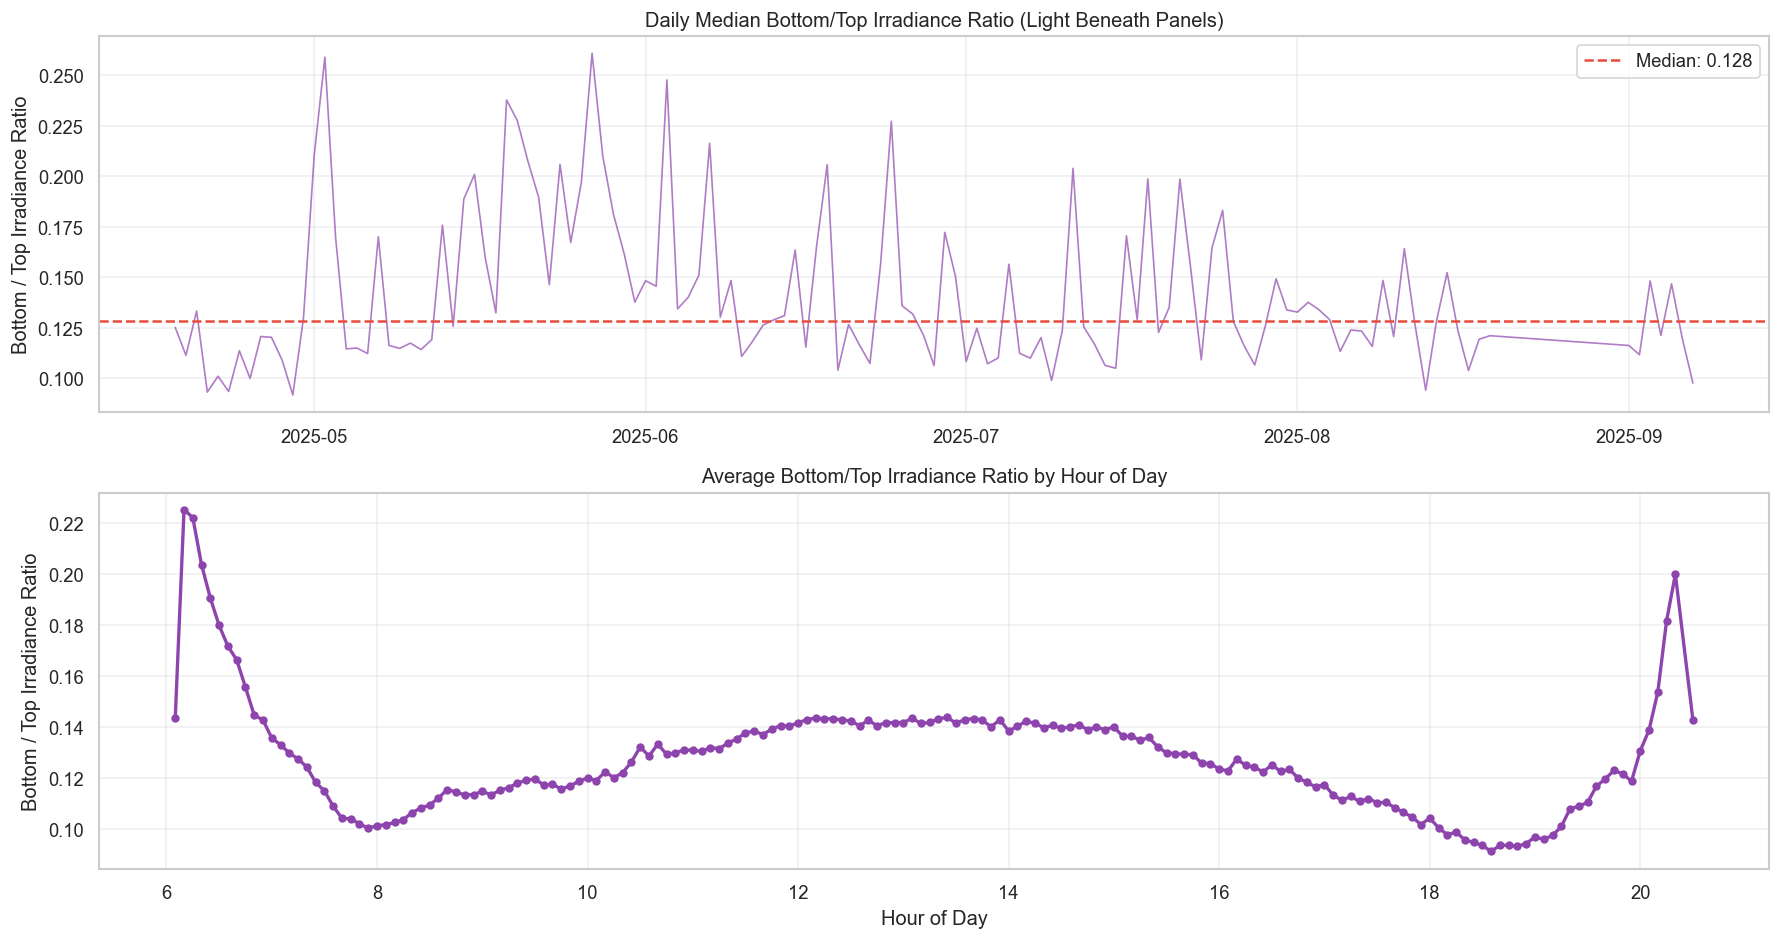

Overall median bottom/top ratio: 0.1283
→ Crops under panels receive ~12.8% of the incident light


In [24]:
# Bottom/top irradiance ratio over time — indicator of light availability for crops
df_day["irr_ratio"] = np.where(df_day["irr_top"] > 50,
                                df_day["irr_bottom"] / df_day["irr_top"], np.nan)

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Plot 1: Daily median bottom/top ratio
daily_ratio = df_day.groupby("date")["irr_ratio"].median()
axes[0].plot(daily_ratio.index, daily_ratio.values, color="#8e44ad", linewidth=1, alpha=0.7)
axes[0].axhline(daily_ratio.median(), color="#e74c3c", linestyle="--",
                label=f"Median: {daily_ratio.median():.3f}")
axes[0].set_ylabel("Bottom / Top Irradiance Ratio")
axes[0].set_title("Daily Median Bottom/Top Irradiance Ratio (Light Beneath Panels)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Hourly profile of bottom/top ratio
hourly_ratio = df_day.groupby("hour")["irr_ratio"].median()
axes[1].plot(hourly_ratio.index, hourly_ratio.values, color="#8e44ad", linewidth=2, marker="o", markersize=4)
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Bottom / Top Irradiance Ratio")
axes[1].set_title("Average Bottom/Top Irradiance Ratio by Hour of Day")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Overall median bottom/top ratio: {daily_ratio.median():.4f}")
print(f"→ Crops under panels receive ~{daily_ratio.median()*100:.1f}% of the incident light")

## B10. Effect Size Summary & Crop Ranking

=== Crop Effect Size Ranking (vs Control, Dedicated MPPT Only) ===

 crop_group  mean_pr  pct_of_control  cohens_d effect_magnitude direction  n_observations
Polli mix 1 8.022414      102.173991  0.303002            small    higher             384
  Raspberry 7.914110      100.794624  0.109916       negligible    higher             128
 Strawberry 7.840545       99.857700 -0.020075       negligible     lower             384
     Pepper 7.766738       98.917685 -0.154782       negligible     lower             256
   Broccoli 7.734755       98.510349 -0.221828            small     lower             256


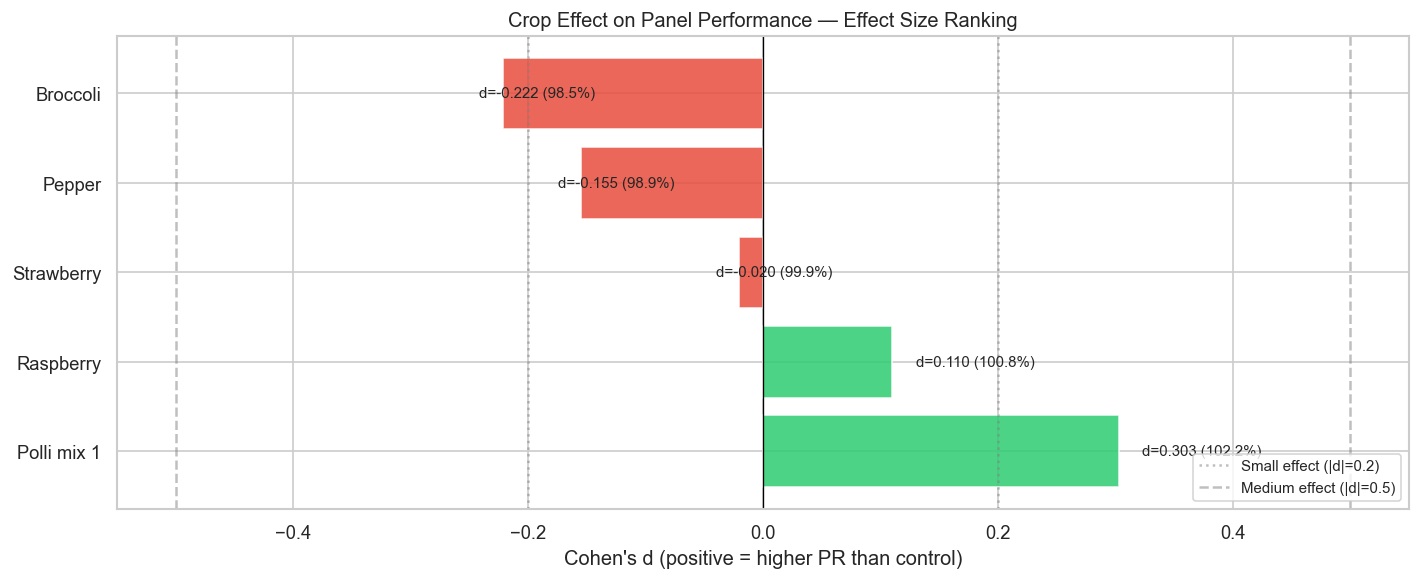

In [25]:
# Effect size: Cohen's d (crop group median PR vs control median PR)
control_vals = np.concatenate([
    daily_pr[f"pr_{p}"].dropna().values
    for p in control_panels["panel"]
])
control_mean = control_vals.mean()
control_std = control_vals.std()

effect_sizes = []
for grp, sub in ded_panels_list.groupby("crop_group"):
    if grp == "Control":
        continue
    grp_vals = np.concatenate([
        daily_pr[f"pr_{p}"].dropna().values
        for _, row in sub.iterrows()
        if f"pr_{row['panel']}" in daily_pr.columns
        for p in [row["panel"]]
    ])
    grp_mean = grp_vals.mean()
    grp_std = grp_vals.std()

    # Pooled std for Cohen's d
    pooled_std = np.sqrt(((len(control_vals) - 1) * control_std**2 +
                          (len(grp_vals) - 1) * grp_std**2) /
                         (len(control_vals) + len(grp_vals) - 2))
    cohens_d = (grp_mean - control_mean) / pooled_std if pooled_std > 0 else 0

    effect_sizes.append({
        "crop_group": grp,
        "mean_pr": grp_mean,
        "pct_of_control": grp_mean / control_mean * 100,
        "cohens_d": cohens_d,
        "effect_magnitude": (
            "negligible" if abs(cohens_d) < 0.2 else
            "small" if abs(cohens_d) < 0.5 else
            "medium" if abs(cohens_d) < 0.8 else
            "large"
        ),
        "direction": "higher" if cohens_d > 0 else "lower",
        "n_observations": len(grp_vals),
    })

effect_df = pd.DataFrame(effect_sizes).sort_values("cohens_d", ascending=False)

print("=== Crop Effect Size Ranking (vs Control, Dedicated MPPT Only) ===\n")
print(effect_df.to_string(index=False))

# Visual summary
fig, ax = plt.subplots(figsize=(12, 5))
colors_bar = ["#2ecc71" if d > 0 else "#e74c3c" for d in effect_df["cohens_d"]]
bars = ax.barh(effect_df["crop_group"], effect_df["cohens_d"], color=colors_bar, edgecolor="white", alpha=0.85)

ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(0.2, color="gray", linestyle=":", alpha=0.5, label="Small effect (|d|=0.2)")
ax.axvline(-0.2, color="gray", linestyle=":", alpha=0.5)
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="Medium effect (|d|=0.5)")
ax.axvline(-0.5, color="gray", linestyle="--", alpha=0.5)

for bar, row in zip(bars, effect_df.itertuples()):
    ax.text(bar.get_width() + 0.02 * (1 if bar.get_width() >= 0 else -1),
            bar.get_y() + bar.get_height() / 2,
            f"d={row.cohens_d:.3f} ({row.pct_of_control:.1f}%)",
            va="center", fontsize=9)

ax.set_xlabel("Cohen's d (positive = higher PR than control)")
ax.set_title("Crop Effect on Panel Performance — Effect Size Ranking")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## B11. Limitations & Final Summary

In [26]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║           PERFORMANCE BENCHMARKING — FINAL SUMMARY             ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  METHODOLOGY                                                     ║
║  ─────────────────────────────────────────────────────────────── ║
║  • Performance Ratio (PR) = Panel Power / Site Irradiance        ║
║  • Normalizes for weather/season; isolates panel-level effects   ║
║  • Daytime only (irr > 50 W/m²) per IEC 61724 standard          ║
║  • Zeros treated as missing (technical issues or no data)        ║
║  • IQR × 3 upper fence for outlier removal                       ║
║  • Kruskal-Wallis + Dunn's/Mann-Whitney for group comparisons   ║
║  • Cohen's d for effect size quantification                      ║
║                                                                  ║
║  DATA SCOPE                                                      ║
║  ─────────────────────────────────────────────────────────────── ║
║  • 24 panels, 7 crop types + control group                       ║
║  • April – September 2025, 5-minute resolution                   ║
║  • 7 panels excluded (technical issues): eu_5,6,7,13,14,21,22   ║
║  • 17 usable panels (14 dedicated MPPT, 3 shared MPPT pairs)    ║
║                                                                  ║
║  LIMITATIONS                                                     ║
║  ─────────────────────────────────────────────────────────────── ║
║  1. Low replication: 1-3 panels per crop (small N)               ║
║  2. Site-level irradiance only (no per-panel irradiance)         ║
║  3. Shared MPPT panels analyzed separately (confounded output)   ║
║  4. No panel temperature data (PR_STC not possible)              ║
║  5. Panel orientation/tilt assumed identical                      ║
║  6. 7/24 panels unusable — some groups have just 1 panel         ║
║  7. Crop growth stages not timestamped (approx via season)       ║
║                                                                  ║
║  INTERPRETATION GUIDE                                            ║
║  ─────────────────────────────────────────────────────────────── ║
║  • Differences < |d| = 0.2 are likely noise                      ║
║  • Shared-MPPT panels will show ~lower PR (known hardware bias)  ║
║  • Weekly trends show seasonal crop growth effects               ║
║  • Groups with only 1 usable panel have no internal consistency  ║
║    check — treat those results with extra caution                ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")

# Print crop ranking (quick reference)
print("CROP RANKING (by Cohen's d vs Control, dedicated MPPT only):")
print("=" * 60)
for i, row in enumerate(effect_df.itertuples(), 1):
    arrow = "↑" if row.cohens_d > 0 else "↓"
    print(f"  {i}. {row.crop_group:15s} {arrow} d={row.cohens_d:+.3f}  ({row.pct_of_control:.1f}% of control)  [{row.effect_magnitude}]")

print(f"\n{'='*60}")
print(f"Control baseline PR: {control_mean:.4f}")
print(f"Usable panels: {panel_meta['usable'].sum()}/24")
print(f"Excluded (technical issues): {(~panel_meta['usable']).sum()}/24")


╔══════════════════════════════════════════════════════════════════╗
║           PERFORMANCE BENCHMARKING — FINAL SUMMARY             ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  METHODOLOGY                                                     ║
║  ─────────────────────────────────────────────────────────────── ║
║  • Performance Ratio (PR) = Panel Power / Site Irradiance        ║
║  • Normalizes for weather/season; isolates panel-level effects   ║
║  • Daytime only (irr > 50 W/m²) per IEC 61724 standard          ║
║  • Zeros treated as missing (technical issues or no data)        ║
║  • IQR × 3 upper fence for outlier removal                       ║
║  • Kruskal-Wallis + Dunn's/Mann-Whitney for group comparisons   ║
║  • Cohen's d for effect size quantification                      ║
║                                                                  ║
║  DATA SCOPE                        